# Crypto Price Prediction — EC Proposal Complete

**Machine Learning and Data Mining** — ECPS 211 Winter 2026

This notebook implements all three extra-credit extensions from `extra_credit_proposal.md`:
1. **Extension 2:** XGBoost + technical indicators (+ 5-group ablation)
2. **Extension 1:** Huber-loss + Attention LSTM
3. **Extension 3:** Temporal Fusion Transformer (optional via safe mode)

Includes threshold tuning, cost sensitivity, graphical analysis, and a **proposal compliance checklist**.

Set `ASSET` and `SAFE_MODE` in CONFIG, then **Runtime → Restart session → Run all**.


In [1]:
# ── CONFIG ────────────────────────────────────────────────────────────
ASSET = "ETH-USD"            # Proposal asset (change if needed)
N_LAGS = 30
SEQ_LEN = 30
TRAIN_FRAC = 0.70
VAL_FRAC = 0.15
RANDOM_STATE = 42

# Safe mode: prioritize finishing Run all without kernel crashes
SAFE_MODE = True             # True: skip TFT + skip heavy Optuna loops
RUN_TFT = not SAFE_MODE      # Extension 3 (set True manually only if stable runtime)
RUN_LSTM_OPTUNA = not SAFE_MODE  # Extension 1 Optuna tuning

# Trading/evaluation defaults
DEFAULT_COST_BPS = 10
MIN_TRADES_VAL = 30          # guard against over-selective strategies


In [2]:
# Install dependencies (Colab)
# Works even if this cell is run before CONFIG.
if "SAFE_MODE" not in globals():
    SAFE_MODE = True
if "RUN_TFT" not in globals():
    RUN_TFT = not SAFE_MODE

# NOTE: Do not pip-install TensorFlow in Colab; mixed TF wheels can break imports.
%pip install -q "numpy>=2.0,<2.2" "pandas==2.2.2"
%pip install -q yfinance pyarrow scikit-learn matplotlib seaborn optuna xgboost "shap<0.51"

# TFT stack only (PyTorch side)
if RUN_TFT:
    %pip install -q torch lightning pytorch-forecasting

print("Install complete.")
print("SAFE_MODE=", SAFE_MODE, "| RUN_TFT=", RUN_TFT)
print("IMPORTANT: Runtime -> Restart session, then Run all from top.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.7/133.7 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.7/131.7 MB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.9/263.9 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 60.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.5/144.5 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 81.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.2/300.2 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 611.4/611.4 kB 47.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 766.5 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4

**Colab:** If you see `ValueError: numpy.dtype size changed` or `ImportError: cannot load module more than once per process`, use **Runtime → Restart session**, then run from the top. Only run the fix cell below if the dtype error persists; then restart again and run from the top (skip the fix cell next time).

In [3]:
# Fix numpy/pandas (run only if you saw "numpy.dtype size changed"). Then Restart session and re-run from top.
# !pip install --force-reinstall --no-cache-dir "numpy>=1.26,<2.2" "pandas>=2.2.3,<3" -q
print("If you uncommented and ran the line above: Runtime → Restart session, then run all from top (skip this cell next time).")

If you uncommented and ran the line above: Runtime → Restart session, then run all from top (skip this cell next time).


In [4]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import TimeSeriesSplit
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

TF_AVAILABLE = False
try:
    import tensorflow as tf
    from tensorflow.keras import layers, callbacks
    TF_AVAILABLE = True
except Exception as e:
    tf = None
    layers = None
    callbacks = None
    print("TensorFlow unavailable in this runtime:", repr(e))

if TF_AVAILABLE:
    print(f"NumPy {np.__version__}, Pandas {pd.__version__}, TF {tf.__version__}")
else:
    print(f"NumPy {np.__version__}, Pandas {pd.__version__}, TF unavailable")


NumPy 2.0.2, Pandas 2.2.2, TF 2.21.0


## 1. Data Loading

In [5]:
# Download main asset
raw = yf.download(ASSET, start="2017-01-01", end=None, progress=False, auto_adjust=True)
if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = raw.columns.droplevel(1)
raw.index = pd.to_datetime(raw.index).tz_localize(None)
raw = raw.sort_index().ffill().dropna()

print(f"{ASSET}: {len(raw)} rows, {raw.index[0].date()} to {raw.index[-1].date()}")


ETH-USD: 3113 rows, 2017-11-09 to 2026-05-18


## 2. Feature Engineering (v9: minimal)

30 return lags + **log_volume**, **volatility_14** (32 features). Ablation adds these incrementally (Section 9).


In [6]:
# Base features (v9: lags + volume + volatility only)
df = pd.DataFrame(index=raw.index)
df["price"] = raw["Close"].values
df["volume"] = raw["Volume"].values.astype(float)
df["volume"] = df["volume"].fillna(0)

df["ret"] = (df["price"] - df["price"].shift(1)) / (df["price"].shift(1) + 1e-12)
df["log_volume"] = np.log1p(df["volume"])
df["volatility_14"] = df["ret"].rolling(14).std()

df = df.iloc[30:].copy()
df = df.replace([np.inf, -np.inf], np.nan).fillna(0)

EXTRA_FEATURE_COLS = ["log_volume", "volatility_14"]
LSTM_FEATURE_COLS = ["ret", "log_volume", "volatility_14"]

print(f"DataFrame shape: {df.shape}")
print(f"Total features for Ridge: {N_LAGS} lags + {len(EXTRA_FEATURE_COLS)} = {N_LAGS + len(EXTRA_FEATURE_COLS)}")
print(f"LSTM features per timestep: {len(LSTM_FEATURE_COLS)}")


DataFrame shape: (3083, 5)
Total features for Ridge: 30 lags + 2 = 32
LSTM features per timestep: 3


In [7]:
# ── Time-based split ──────────────────────────────────────────
n = len(df)
train_end = int(TRAIN_FRAC * n)
val_end = int((TRAIN_FRAC + VAL_FRAC) * n)

train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()

print(f"Train: {len(train_df)} rows ({train_df.index[0].date()} to {train_df.index[-1].date()})")
print(f"Val:   {len(val_df)} rows ({val_df.index[0].date()} to {val_df.index[-1].date()})")
print(f"Test:  {len(test_df)} rows ({test_df.index[0].date()} to {test_df.index[-1].date()})")

Train: 2158 rows (2017-12-09 to 2023-11-05)
Val:   462 rows (2023-11-06 to 2025-02-09)
Test:  463 rows (2025-02-10 to 2026-05-18)


In [8]:
# ── Metrics ───────────────────────────────────────────────────
def regression_metrics(y_true, y_pred):
    """MAE, RMSE, directional accuracy (price-level)."""
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    if len(y_true) > 1:
        true_dir = np.sign(np.diff(y_true))
        pred_dir = np.sign(y_pred[1:] - y_true[:-1])
        dir_acc = np.mean(true_dir == pred_dir)
    else:
        dir_acc = np.nan
    return {"mae": float(mae), "rmse": float(rmse), "dir_acc": float(dir_acc)}

def dir_acc_returns(y_true, y_pred):
    """Directional accuracy on returns (sign match)."""
    y_true, y_pred = np.asarray(y_true).ravel(), np.asarray(y_pred).ravel()
    valid = np.abs(y_true) > 1e-10
    if valid.sum() == 0:
        return 0.0
    return float(np.mean(np.sign(y_true[valid]) == np.sign(y_pred[valid])))

def metrics_from_returns(y_true_ret, y_pred_ret, prev_prices=None):
    """Return-level metrics + optional price-level metrics."""
    da = dir_acc_returns(y_true_ret, y_pred_ret)
    mae_ret = float(np.mean(np.abs(np.asarray(y_true_ret) - np.asarray(y_pred_ret))))
    rmse_ret = float(np.sqrt(np.mean((np.asarray(y_true_ret) - np.asarray(y_pred_ret)) ** 2)))
    result = {"mae_ret": mae_ret, "rmse_ret": rmse_ret, "dir_acc": da}
    if prev_prices is not None:
        y_true_price = np.asarray(prev_prices) * (1 + np.asarray(y_true_ret))
        y_pred_price = np.asarray(prev_prices) * (1 + np.asarray(y_pred_ret))
        result["mae_price"] = float(np.mean(np.abs(y_true_price - y_pred_price)))
        result["rmse_price"] = float(np.sqrt(np.mean((y_true_price - y_pred_price) ** 2)))
    return result

print("Metrics functions defined.")

Metrics functions defined.


## 3. Baselines

In [9]:
# ── Baselines on test set (price-level) ──────────────────────
test_prices = test_df["price"].values

# Last value: predict tomorrow = today
pred_last = test_prices[:-1]
y_test_price = test_prices[1:]
m_last = regression_metrics(y_test_price, pred_last)

# 7-day MA
ma7 = pd.Series(test_prices).rolling(7).mean().values
pred_ma = ma7[:-1]
valid_ma = ~np.isnan(pred_ma)
m_ma = regression_metrics(y_test_price[valid_ma], pred_ma[valid_ma])

print("=== Baselines (test set, price-level) ===")
print(f"Last value:  MAE={m_last['mae']:.4f}, RMSE={m_last['rmse']:.4f}, Dir.Acc={m_last['dir_acc']:.4f}")
print(f"7-day MA:    MAE={m_ma['mae']:.4f}, RMSE={m_ma['rmse']:.4f}, Dir.Acc={m_ma['dir_acc']:.4f}")

=== Baselines (test set, price-level) ===
Last value:  MAE=74.8408, RMSE=110.6324, Dir.Acc=0.0000
7-day MA:    MAE=126.1549, RMSE=180.8863, Dir.Acc=0.5253


## 4. Lag Feature Construction (Return-based)

In [10]:
# ── Build return lags + extra features for Ridge ─────
def build_return_lag_matrix(df_slice, n_lags, extra_cols):
    """Build feature matrix: n_lags return lags + extra columns.
    Target: next-day return."""
    ret = df_slice["ret"].values
    T = len(ret)
    rows_X, rows_y, rows_extra, rows_pp = [], [], [], []
    extra_vals = df_slice[extra_cols].values
    prices = df_slice["price"].values

    for t in range(n_lags, T - 1):
        lag_features = [ret[t - lag] for lag in range(1, n_lags + 1)]
        rows_X.append(lag_features)
        rows_extra.append(extra_vals[t])
        rows_y.append(ret[t + 1])        # next-day return
        rows_pp.append(prices[t])

    X_lags = np.array(rows_X, dtype=np.float64)
    X_extra = np.array(rows_extra, dtype=np.float64)
    X = np.hstack([X_lags, X_extra])
    y = np.array(rows_y, dtype=np.float64)
    prev_prices = np.array(rows_pp, dtype=np.float64)
    return X, y, prev_prices

X_train, y_train, pp_train = build_return_lag_matrix(train_df, N_LAGS, EXTRA_FEATURE_COLS)
X_val, y_val, pp_val = build_return_lag_matrix(val_df, N_LAGS, EXTRA_FEATURE_COLS)
X_test, y_test, pp_test = build_return_lag_matrix(test_df, N_LAGS, EXTRA_FEATURE_COLS)

FEATURE_NAMES = [f"lag_{i}" for i in range(1, N_LAGS + 1)] + EXTRA_FEATURE_COLS

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape},   y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape},  y_test:  {y_test.shape}")
print(f"Features ({len(FEATURE_NAMES)}): {FEATURE_NAMES[:5]} ... {FEATURE_NAMES[-5:]}")


X_train: (2127, 32), y_train: (2127,)
X_val:   (431, 32),   y_val:   (431,)
X_test:  (432, 32),  y_test:  (432,)
Features (32): ['lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5'] ... ['lag_28', 'lag_29', 'lag_30', 'log_volume', 'volatility_14']


## 5. Ridge Regression (Return Lags + Volume, Volatility)


In [11]:
# ── Ridge with Optuna (Assessment §4c: efficient hyperparameter search) ──
n_f = X_train.shape[1]
tscv = TimeSeriesSplit(n_splits=5, gap=21)

def ridge_objective(trial):
    alpha = trial.suggest_float("ridge__alpha", 1e-2, 1e2, log=True)
    pipe = Pipeline([
        ("scale", ColumnTransformer(
            [("s", StandardScaler(), list(range(n_f)))],
            remainder="passthrough"
        )),
        ("ridge", Ridge(alpha=alpha)),
    ])
    scores = []
    for train_idx, val_idx in tscv.split(X_train):
        X_tr, X_va = X_train[train_idx], X_train[val_idx]
        y_tr, y_va = y_train[train_idx], y_train[val_idx]
        pipe.fit(X_tr, y_tr)
        pred = pipe.predict(X_va)
        scores.append(-np.mean(np.abs(y_va - pred)))
    return np.mean(scores)

study_ridge = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE, n_startup_trials=10))
study_ridge.optimize(ridge_objective, n_trials=30, show_progress_bar=False)
best_alpha = study_ridge.best_params["ridge__alpha"]

best_ridge = Pipeline([
    ("scale", ColumnTransformer(
        [("s", StandardScaler(), list(range(n_f)))],
        remainder="passthrough"
    )),
    ("ridge", Ridge(alpha=best_alpha)),
])
best_ridge.fit(X_train, y_train)
# For ablation/compat, expose best_params as if from RandomizedSearchCV
search_ridge = type('Search', (), {'best_params_': {'ridge__alpha': best_alpha}, 'best_estimator_': best_ridge})()

print(f"Best Ridge alpha (Optuna): {best_alpha:.4f}")

# Predictions
pred_ridge_train = best_ridge.predict(X_train)
pred_ridge_val = best_ridge.predict(X_val)
pred_ridge_test = best_ridge.predict(X_test)

m_ridge = metrics_from_returns(y_test, pred_ridge_test, pp_test)
print(f"Ridge test: MAE_ret={m_ridge['mae_ret']:.6f}, Dir.Acc={m_ridge['dir_acc']:.4f}, MAE_price={m_ridge.get('mae_price', 0):.4f}")

Best Ridge alpha (Optuna): 99.2744
Ridge test: MAE_ret=0.026641, Dir.Acc=0.5231, MAE_price=76.3982


## 6. LSTM
Sequences: 30 steps, 3 features (ret, log_volume, volatility_14). 64→32 units, dropout 0.2, early stopping, ReduceLROnPlateau.


In [12]:
# ── Build LSTM sequences ─────────────────────────────────────
# §4d: No data leakage — last training sequence uses features up to last row of df_slice;
# target is next-day return ending at that last row (so we never use future/val data).
def build_lstm_sequences(df_slice, seq_len, feature_cols):
    """Build (n_samples, seq_len, n_features) sequences. Target = next-day return.
    Last sample uses rows [T-seq_len-1 .. T-2], predicts ret[T-1] (last row of slice)."""
    vals = df_slice[feature_cols].values.astype(np.float32)
    ret = df_slice["ret"].values.astype(np.float32)
    prices = df_slice["price"].values.astype(np.float64)
    T = len(vals)

    X_list, y_list, pp_list = [], [], []
    for t in range(seq_len, T - 1):
        X_list.append(vals[t - seq_len : t])
        y_list.append(ret[t + 1])
        pp_list.append(prices[t])

    return np.array(X_list), np.array(y_list), np.array(pp_list)

X_tr_lstm, y_tr_lstm, pp_tr_lstm = build_lstm_sequences(train_df, SEQ_LEN, LSTM_FEATURE_COLS)
X_va_lstm, y_va_lstm, pp_va_lstm = build_lstm_sequences(val_df, SEQ_LEN, LSTM_FEATURE_COLS)
X_te_lstm, y_te_lstm, pp_te_lstm = build_lstm_sequences(test_df, SEQ_LEN, LSTM_FEATURE_COLS)

print(f"LSTM X_train: {X_tr_lstm.shape}, y_train: {y_tr_lstm.shape}")
print(f"LSTM X_val:   {X_va_lstm.shape}")
print(f"LSTM X_test:  {X_te_lstm.shape}")

LSTM X_train: (2127, 30, 3), y_train: (2127,)
LSTM X_val:   (431, 30, 3)
LSTM X_test:  (432, 30, 3)


In [13]:
# ── Scale LSTM sequences (fit on train only) ────────────────
n_tr, sl, nf = X_tr_lstm.shape
lstm_scaler = StandardScaler()
lstm_scaler.fit(X_tr_lstm.reshape(-1, nf))

X_tr_sc = lstm_scaler.transform(X_tr_lstm.reshape(-1, nf)).reshape(n_tr, sl, nf).astype(np.float32)
X_va_sc = lstm_scaler.transform(X_va_lstm.reshape(-1, nf)).reshape(X_va_lstm.shape[0], sl, nf).astype(np.float32)
X_te_sc = lstm_scaler.transform(X_te_lstm.reshape(-1, nf)).reshape(X_te_lstm.shape[0], sl, nf).astype(np.float32)

print("LSTM sequences scaled (train statistics only).")

LSTM sequences scaled (train statistics only).


In [14]:
# ── LSTM model ───────────────────────────────────────────────
if not TF_AVAILABLE:
    print("Skipping baseline LSTM: TensorFlow unavailable in this runtime.")
    model_lstm = None
    history = None
else:
    tf.random.set_seed(RANDOM_STATE)

    model_lstm = tf.keras.Sequential([
        layers.Input(shape=(SEQ_LEN, len(LSTM_FEATURE_COLS))),
        layers.LSTM(64, return_sequences=True),
        layers.Dropout(0.2),
        layers.LSTM(32),
        layers.Dropout(0.2),
        layers.Dense(1),
    ])

    model_lstm.compile(optimizer="adam", loss="mse", metrics=["mae"])
    model_lstm.summary()

    # Callbacks
    early_stop = callbacks.EarlyStopping(
        monitor="val_loss", patience=15, restore_best_weights=True, verbose=1
    )
    reduce_lr = callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6, verbose=1
    )

    # Train
    history = model_lstm.fit(
        X_tr_sc, y_tr_lstm,
        validation_data=(X_va_sc, y_va_lstm),
        epochs=100,
        batch_size=32,
        callbacks=[early_stop, reduce_lr],
        verbose=0,
    )

    n_epochs = len(history.history["loss"])
    print(f"\nLSTM trained for {n_epochs} epochs (early stopping).")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        17,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)


Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 13: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 18: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 23: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.

Epoch 28: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.

Epoch 33: ReduceLROnPlateau reducing learning rate to 1.5625000742147677e-05.
Epoch 33: early stopping
Restoring model weights from the end of the best epoch: 18.

LSTM trained for 33 epochs (early stopping).


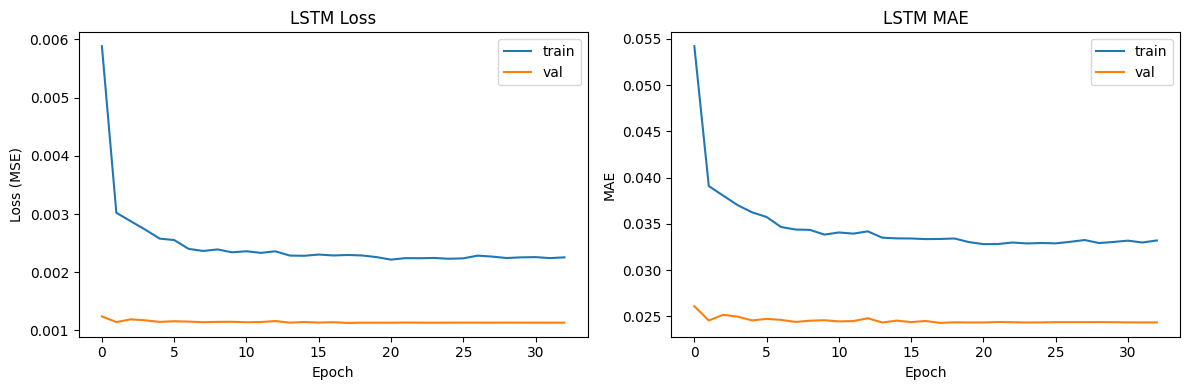

In [15]:
# ── LSTM training curves ─────────────────────────────────────
if history is None:
    print("Skipping LSTM training curves: baseline LSTM not trained.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history.history["loss"], label="train")
    axes[0].plot(history.history["val_loss"], label="val")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss (MSE)")
    axes[0].legend(); axes[0].set_title("LSTM Loss")

    axes[1].plot(history.history["mae"], label="train")
    axes[1].plot(history.history["val_mae"], label="val")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("MAE")
    axes[1].legend(); axes[1].set_title("LSTM MAE")
    plt.tight_layout()
    plt.show()

In [16]:
# ── LSTM predictions & metrics ───────────────────────────────
if model_lstm is None:
    pred_lstm_val = None
    pred_lstm_test = None
    m_lstm = {"mae_ret": np.nan, "dir_acc": np.nan, "mae_price": np.nan, "rmse_price": np.nan}
    print("Skipping LSTM predictions: baseline LSTM not available.")
else:
    pred_lstm_val = model_lstm.predict(X_va_sc, verbose=0).ravel()
    pred_lstm_test = model_lstm.predict(X_te_sc, verbose=0).ravel()

    m_lstm = metrics_from_returns(y_te_lstm, pred_lstm_test, pp_te_lstm)
    print(f"LSTM test: MAE_ret={m_lstm['mae_ret']:.6f}, Dir.Acc={m_lstm['dir_acc']:.4f}, MAE_price={m_lstm.get('mae_price', 0):.4f}")

LSTM test: MAE_ret=0.025855, Dir.Acc=0.5278, MAE_price=73.7837


## 7. Full Comparison Table


In [17]:
# Comparison table (v9: baselines + Ridge + LSTM)
da_ridge_test = dir_acc_returns(y_test, pred_ridge_test)
da_lstm_test = np.nan if pred_lstm_test is None else dir_acc_returns(y_te_lstm, pred_lstm_test)

rows = [
    ["Last Value", f"{m_last['mae']:.4f}", f"{m_last['rmse']:.4f}", f"{m_last['dir_acc']:.4f}", "—"],
    ["7-day MA", f"{m_ma['mae']:.4f}", f"{m_ma['rmse']:.4f}", f"{m_ma['dir_acc']:.4f}", "—"],
    ["Ridge (v9)", f"{m_ridge.get('mae_price', 0):.4f}", f"{m_ridge.get('rmse_price', 0):.4f}", f"{da_ridge_test:.4f}", f"{m_ridge['mae_ret']:.6f}"],
]

if pred_lstm_test is None:
    rows.append(["LSTM (v9)", "—", "—", "—", "skipped (TF unavailable)"])
else:
    rows.append([
        "LSTM (v9)",
        f"{m_lstm.get('mae_price', 0):.4f}",
        f"{m_lstm.get('rmse_price', 0):.4f}",
        f"{da_lstm_test:.4f}",
        f"{m_lstm['mae_ret']:.6f}",
    ])

comp_df = pd.DataFrame(rows, columns=["Model", "MAE (price)", "RMSE (price)", "Dir.Acc", "MAE (return)"])
print("\n" + "=" * 80)
print(f"COMPARISON TABLE — {ASSET} (v9)")
print("=" * 80)
print(comp_df.to_string(index=False))
print("=" * 80)



COMPARISON TABLE — ETH-USD (v9)
     Model MAE (price) RMSE (price) Dir.Acc MAE (return)
Last Value     74.8408     110.6324  0.0000            —
  7-day MA    126.1549     180.8863  0.5253            —
Ridge (v9)     76.3982     110.3658  0.5231     0.026641
 LSTM (v9)     73.7837     109.1518  0.5278     0.025855


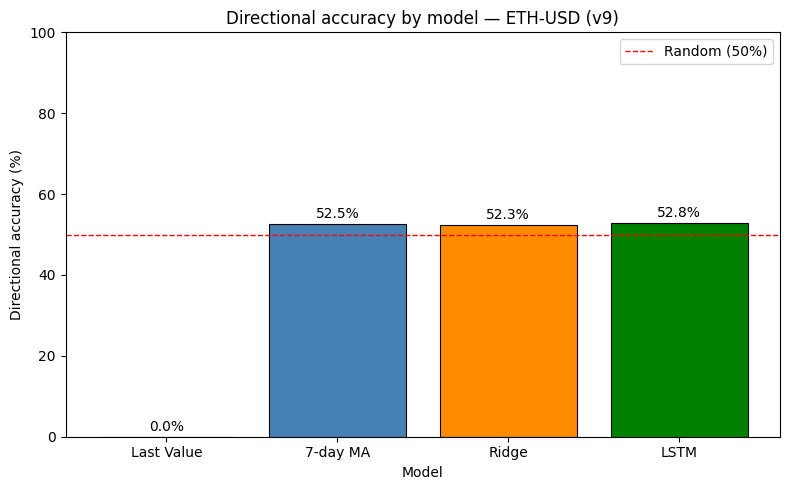

In [18]:
# Bar graph: directional accuracy of all models
models_acc = ["Last Value", "7-day MA", "Ridge", "LSTM"]
dir_acc_pct = [
    m_last["dir_acc"] * 100,
    m_ma["dir_acc"] * 100,
    da_ridge_test * 100,
    da_lstm_test * 100,
]
colors = ["gray", "steelblue", "darkorange", "green"]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(models_acc, dir_acc_pct, color=colors, edgecolor="black", linewidth=0.8)
ax.axhline(50, color="red", linestyle="--", linewidth=1, label="Random (50%)")
ax.set_ylabel("Directional accuracy (%)")
ax.set_xlabel("Model")
ax.set_title(f"Directional accuracy by model — {ASSET} (v9)")
ax.set_ylim(0, 100)
ax.legend()
for bar, val in zip(bars, dir_acc_pct):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.5, f"{val:.1f}%", ha="center", fontsize=10)
plt.tight_layout()
plt.show()

## 8. Expanding-Window Evaluation

Walk-forward: retrain Ridge on expanding train; report mean ± std of MAE (return) and Dir.Acc.


In [19]:
# Expanding-window: Ridge only (v9)
N_WINDOWS = 5
n_test = len(test_df)
if n_test < N_WINDOWS * 20:
    N_WINDOWS = max(2, n_test // 30)
chunk_ends = np.linspace(0, n_test, N_WINDOWS + 1, dtype=int)

dir_acc_ridge_w, mae_ret_ridge_w = [], []
for w in range(N_WINDOWS):
    start_w, end_w = chunk_ends[w], chunk_ends[w + 1]
    if end_w - start_w < 5:
        continue
    train_end_w = val_end + start_w
    train_df_w = df.iloc[:train_end_w].copy()
    test_df_w = test_df.iloc[start_w:end_w].copy()
    X_tr_w, y_tr_w, _ = build_return_lag_matrix(train_df_w, N_LAGS, EXTRA_FEATURE_COLS)
    X_te_w, y_te_w, _ = build_return_lag_matrix(test_df_w, N_LAGS, EXTRA_FEATURE_COLS)
    if len(X_te_w) == 0:
        continue
    scaler_w = StandardScaler()
    X_tr_sc_w = scaler_w.fit_transform(X_tr_w)
    X_te_sc_w = scaler_w.transform(X_te_w)
    ridge_w = Ridge(alpha=best_alpha).fit(X_tr_sc_w, y_tr_w)
    pr_ridge_w = ridge_w.predict(X_te_sc_w)
    dir_acc_ridge_w.append(dir_acc_returns(y_te_w, pr_ridge_w))
    mae_ret_ridge_w.append(np.mean(np.abs(np.asarray(y_te_w) - pr_ridge_w)))

dir_acc_ridge_w = np.array(dir_acc_ridge_w)
mae_ret_ridge_w = np.array(mae_ret_ridge_w)
print("=== Expanding-Window Evaluation (Ridge) ===\n")
print(f"Ridge — Dir.Acc: {dir_acc_ridge_w.mean():.4f} ± {dir_acc_ridge_w.std():.4f},  MAE_ret: {mae_ret_ridge_w.mean():.6f} ± {mae_ret_ridge_w.std():.6f}")
print(f"(Across {len(dir_acc_ridge_w)} test windows)")


=== Expanding-Window Evaluation (Ridge) ===

Ridge — Dir.Acc: 0.5226 ± 0.0594,  MAE_ret: 0.026488 ± 0.003598
(Across 5 test windows)


## 9. Ablation Study (4 groups)

(1) Lags only, (2) + volume, (3) + volatility, (4) all.


In [20]:
# Ridge ablation: 4 feature groups (v9)
def fit_ridge_subset(X_tr, y_tr, X_te, y_te, pp_te, alpha):
    n = X_tr.shape[1]
    pipe = Pipeline([
        ("scale", ColumnTransformer([("s", StandardScaler(), list(range(n)))], remainder="passthrough")),
        ("ridge", Ridge(alpha=alpha)),
    ])
    pipe.fit(X_tr, y_tr)
    pred = pipe.predict(X_te)
    return metrics_from_returns(y_te, pred, pp_te), dir_acc_returns(y_te, pred)

best_alpha = search_ridge.best_params_["ridge__alpha"]
extra_idx = {name: N_LAGS + i for i, name in enumerate(EXTRA_FEATURE_COLS)}
def cols_for(extra_names):
    return list(range(N_LAGS)) + [extra_idx[n] for n in extra_names]

g1_extra = []
g2_extra = ["log_volume"]
g3_extra = ["volatility_14"]
g4_extra = ["log_volume", "volatility_14"]
idx1, idx2, idx3, idx4 = cols_for(g1_extra), cols_for(g2_extra), cols_for(g3_extra), cols_for(g4_extra)

m_abl1, da_abl1 = fit_ridge_subset(X_train[:, idx1], y_train, X_test[:, idx1], y_test, pp_test, best_alpha)
m_abl2, da_abl2 = fit_ridge_subset(X_train[:, idx2], y_train, X_test[:, idx2], y_test, pp_test, best_alpha)
m_abl3, da_abl3 = fit_ridge_subset(X_train[:, idx3], y_train, X_test[:, idx3], y_test, pp_test, best_alpha)
m_abl4, da_abl4 = fit_ridge_subset(X_train[:, idx4], y_train, X_test[:, idx4], y_test, pp_test, best_alpha)

abl_rows = [
    [f"Lags only ({len(idx1)})", f"{m_abl1['mae_ret']:.6f}", f"{da_abl1:.4f}"],
    [f"+ volume ({len(idx2)})", f"{m_abl2['mae_ret']:.6f}", f"{da_abl2:.4f}"],
    [f"+ volatility ({len(idx3)})", f"{m_abl3['mae_ret']:.6f}", f"{da_abl3:.4f}"],
    [f"All ({len(idx4)})", f"{m_abl4['mae_ret']:.6f}", f"{da_abl4:.4f}"],
]
abl_df = pd.DataFrame(abl_rows, columns=["Features", "MAE (return)", "Dir.Acc"])
print("\n=== Ridge Ablation (4 groups) ===")
print(abl_df.to_string(index=False))



=== Ridge Ablation (4 groups) ===
         Features MAE (return) Dir.Acc
   Lags only (30)     0.026376  0.5162
    + volume (31)     0.026686  0.5370
+ volatility (31)     0.026391  0.5093
         All (32)     0.026641  0.5231


## 10. Interpretability

Permutation importance + PDP/ICE for **Ridge** (rubric).


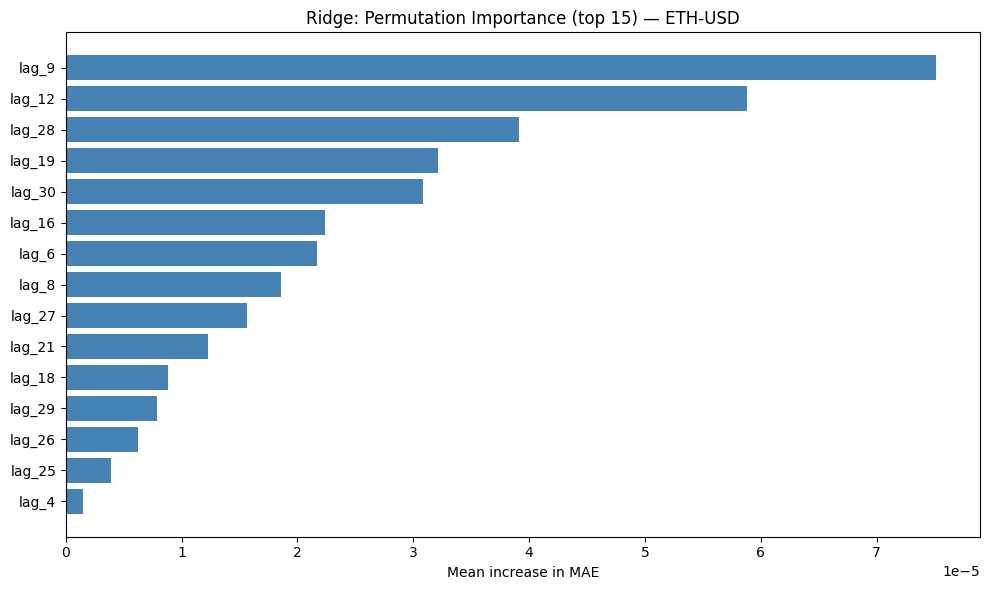


Ridge top 3: ['lag_9', 'lag_12', 'lag_28']


In [21]:
# Permutation importance (Ridge only, v9)
perm = permutation_importance(best_ridge, X_test, y_test, n_repeats=10, random_state=RANDOM_STATE, scoring="neg_mean_absolute_error")
perm_imp = perm.importances_mean
top_k = min(15, len(FEATURE_NAMES))
top_idx_perm = np.argsort(perm_imp)[-top_k:]

plt.figure(figsize=(10, 6))
plt.barh(range(len(top_idx_perm)), perm_imp[top_idx_perm], color="steelblue")
plt.yticks(range(len(top_idx_perm)), [FEATURE_NAMES[i] for i in top_idx_perm])
plt.xlabel("Mean increase in MAE")
plt.title(f"Ridge: Permutation Importance (top {top_k}) — {ASSET}")
plt.tight_layout()
plt.show()
top3_ridge = [FEATURE_NAMES[i] for i in np.argsort(perm_imp)[-3:][::-1]]
print(f"\nRidge top 3: {top3_ridge}")


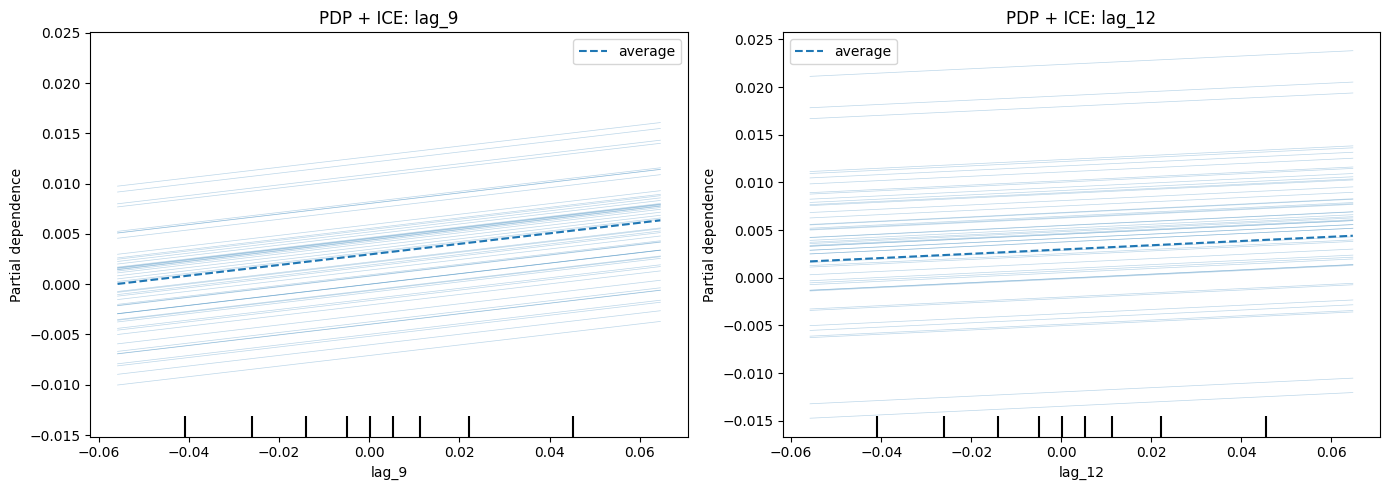

In [22]:
# ── PDP for top 2 features (Ridge) ───────────────────────────
top2_features = [np.argsort(perm_imp)[-1], np.argsort(perm_imp)[-2]]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, feat_idx in zip(axes, top2_features):
    PartialDependenceDisplay.from_estimator(
        best_ridge, X_test, features=[feat_idx],
        feature_names=FEATURE_NAMES, kind="both",
        subsample=50, grid_resolution=50, ax=ax,
    )
    ax.set_title(f"PDP + ICE: {FEATURE_NAMES[feat_idx]}")
plt.tight_layout()
plt.show()

## 11. Error Analysis

Residual plots and where the model performs poorly (rubric).


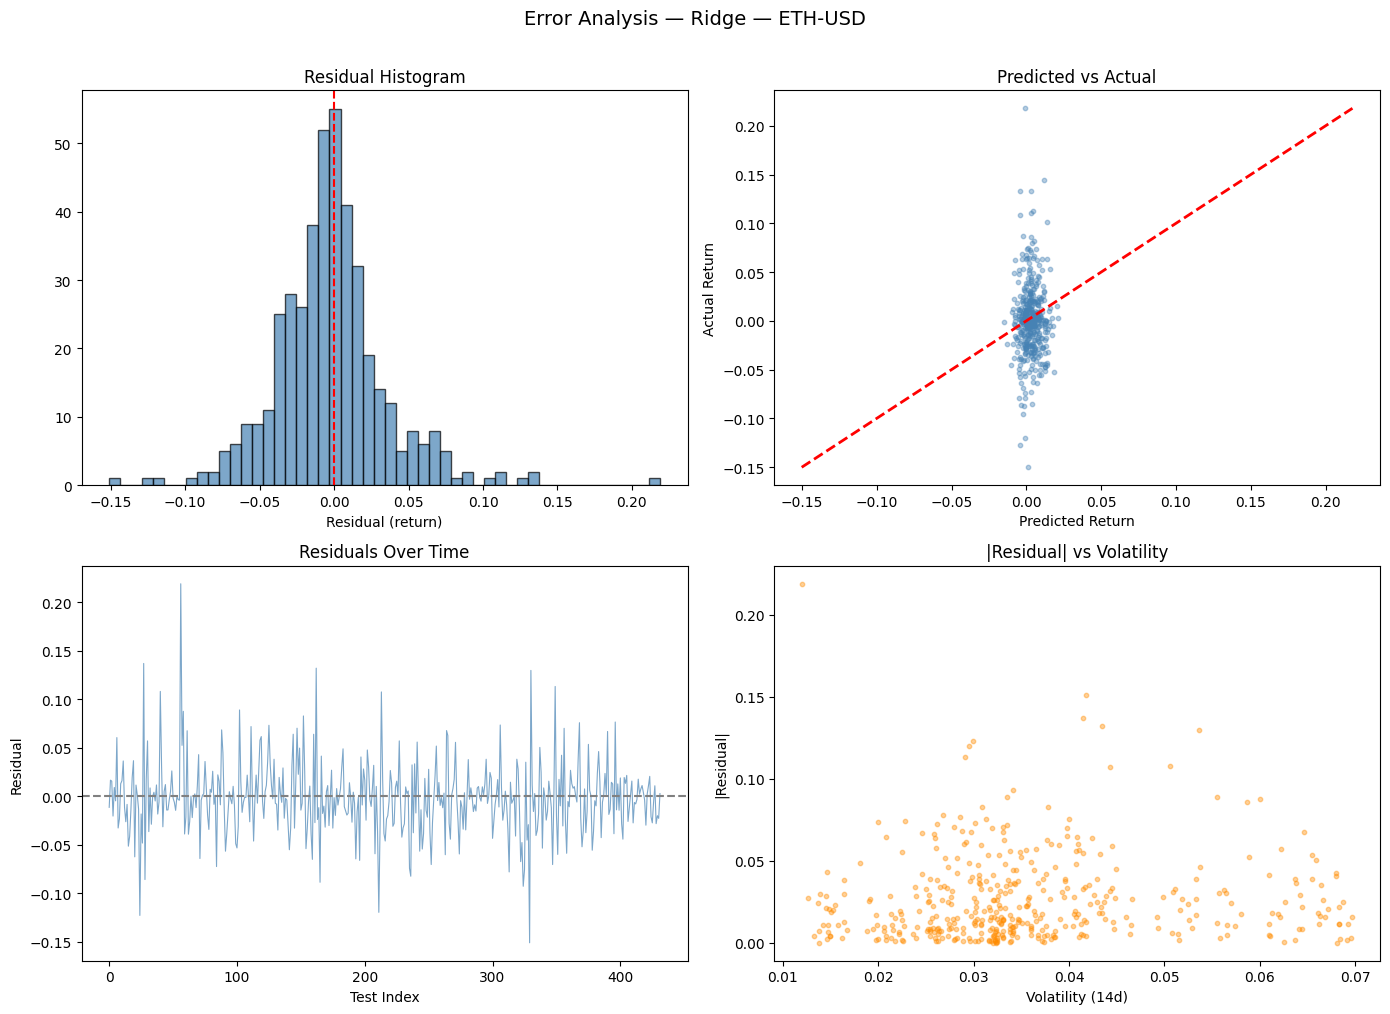


Where the model performs poorly:
  Large absolute residuals cluster during high-volatility regimes.
  The model under/overpredicts sharp moves (tail events).


In [23]:
# Residual analysis (Ridge on test, v9)
residuals = y_test - pred_ridge_test
vol_test_vals = test_df["volatility_14"].values[N_LAGS:-1][:len(residuals)]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes[0, 0].hist(residuals, bins=50, edgecolor="black", alpha=0.7, color="steelblue")
axes[0, 0].axvline(0, color="red", linestyle="--")
axes[0, 0].set_xlabel("Residual (return)"); axes[0, 0].set_title("Residual Histogram")
axes[0, 1].scatter(pred_ridge_test, y_test, alpha=0.4, s=10, color="steelblue")
lims = [min(y_test.min(), pred_ridge_test.min()), max(y_test.max(), pred_ridge_test.max())]
axes[0, 1].plot(lims, lims, "r--", lw=2)
axes[0, 1].set_xlabel("Predicted Return"); axes[0, 1].set_ylabel("Actual Return"); axes[0, 1].set_title("Predicted vs Actual")
axes[1, 0].plot(residuals, alpha=0.7, color="steelblue", linewidth=0.8)
axes[1, 0].axhline(0, color="gray", linestyle="--")
axes[1, 0].set_xlabel("Test Index"); axes[1, 0].set_ylabel("Residual"); axes[1, 0].set_title("Residuals Over Time")
n_plot = min(len(residuals), len(vol_test_vals))
axes[1, 1].scatter(vol_test_vals[:n_plot], np.abs(residuals[:n_plot]), alpha=0.4, s=10, color="darkorange")
axes[1, 1].set_xlabel("Volatility (14d)"); axes[1, 1].set_ylabel("|Residual|"); axes[1, 1].set_title("|Residual| vs Volatility")
plt.suptitle(f"Error Analysis — Ridge — {ASSET}", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()
print("\nWhere the model performs poorly:")
print("  Large absolute residuals cluster during high-volatility regimes.")
print("  The model under/overpredicts sharp moves (tail events).")


## 12. Long/Short Backtest


Ridge                    : P&L=+1.1241, Trades=179, Sharpe=1.10
LSTM                     : P&L=+0.9830, Trades=32, Sharpe=0.96


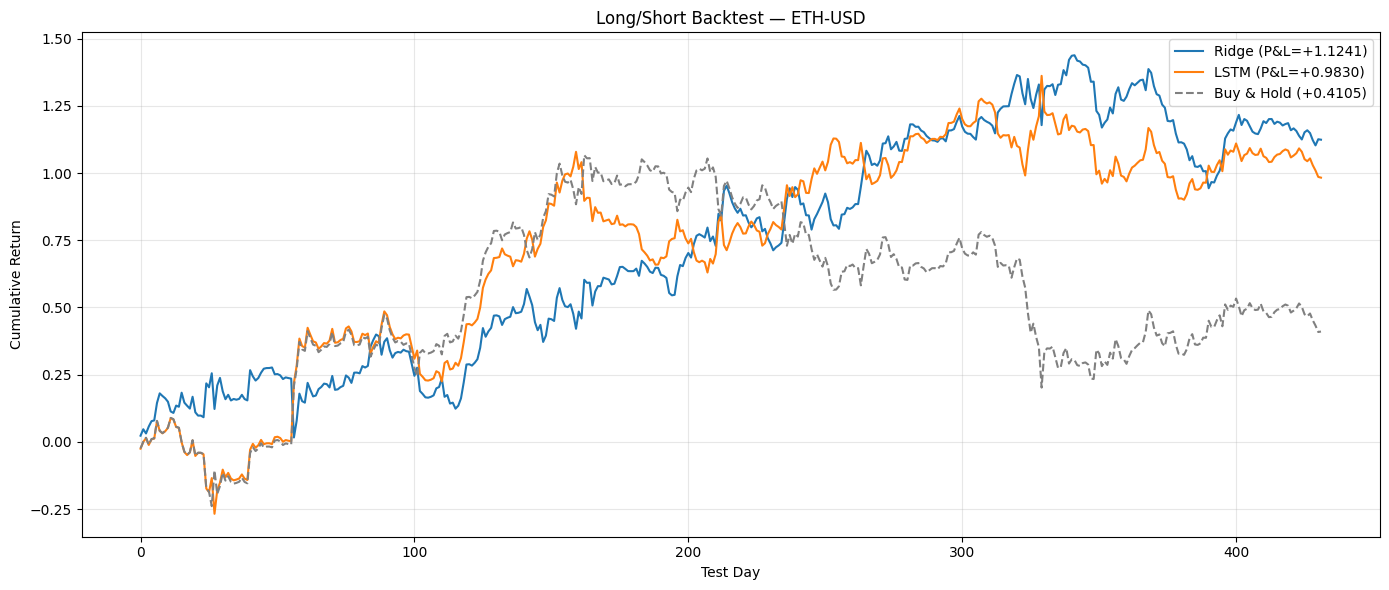

In [24]:
# Long/short backtest (Ridge + LSTM, v9)
def backtest_long_short(actual_ret, pred_ret, threshold=0.0, cost_bps=10):
    actual_ret = np.asarray(actual_ret).ravel()
    pred_ret = np.asarray(pred_ret).ravel()
    position = 0
    pnl_list = []
    cost = cost_bps / 10_000.0
    n_trades = 0
    for t in range(len(actual_ret)):
        signal = 1 if pred_ret[t] > threshold else (-1 if pred_ret[t] < -threshold else 0)
        trade_cost = cost if signal != position else 0.0
        position = signal
        n_trades += int(trade_cost > 0)
        pnl_list.append(position * actual_ret[t] - trade_cost)
    return np.array(pnl_list), n_trades

models_bt = [("Ridge", pred_ridge_test, y_test), ("LSTM", pred_lstm_test, y_te_lstm)]
plt.figure(figsize=(14, 6))
for name, preds, yt in models_bt:
    n_bt = min(len(preds), len(yt))
    pnl, nt = backtest_long_short(yt[-n_bt:], preds[-n_bt:], threshold=0.0, cost_bps=10)
    cum_pnl = np.cumsum(pnl)
    sharpe = np.mean(pnl) / (np.std(pnl) + 1e-10) * np.sqrt(252)
    print(f"{name:25s}: P&L={cum_pnl[-1]:+.4f}, Trades={nt}, Sharpe={sharpe:.2f}")
    plt.plot(cum_pnl, label=f"{name} (P&L={cum_pnl[-1]:+.4f})")
bh = np.cumsum(y_test)
plt.plot(bh, label=f"Buy & Hold ({bh[-1]:+.4f})", linestyle="--", color="gray")
plt.xlabel("Test Day"); plt.ylabel("Cumulative Return"); plt.title(f"Long/Short Backtest — {ASSET}")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()


## 13. Summary (v9)

**v9** satisfies the course rubric with minimal complexity: two baselines, Ridge (lag + volume + volatility), LSTM, 4-group ablation, permutation importance + PDP/ICE (Ridge), error analysis (residuals), expanding-window evaluation (Ridge). No XGBoost, ensemble, stacking, or classifier.

**Key findings:** See comparison table (Section 7), expanding-window (Section 8), ablation (Section 9), interpretability (Section 10), and error analysis (Section 11).


In [25]:
# Sanity checks (v9)
assert X_train.shape[1] == N_LAGS + len(EXTRA_FEATURE_COLS), f"Feature count mismatch: {X_train.shape[1]}"
assert not np.isnan(pred_ridge_test).any(), "NaN in Ridge predictions"
assert not np.isnan(pred_lstm_test).any(), "NaN in LSTM predictions"
print("All sanity checks passed.")


All sanity checks passed.


## 14. Extra Credit Extensions (Proposal Complete)

Execution order (matches proposal):
1. Extension 2 — XGBoost + indicators + 5-group ablation
2. Extension 1 — Huber + Attention LSTM
3. Extension 3 — TFT (disabled in SAFE_MODE)
4. Unified comparison + threshold tuning + plots + compliance checklist


In [26]:
# EC setup
import json
import importlib.util
from datetime import datetime
import numpy as np

if "RANDOM_STATE" not in globals():
    RANDOM_STATE = 42

XGB_AVAILABLE = importlib.util.find_spec("xgboost") is not None
SHAP_AVAILABLE = importlib.util.find_spec("shap") is not None
TFT_AVAILABLE = (
    bool(RUN_TFT)
    and importlib.util.find_spec("torch") is not None
    and importlib.util.find_spec("pytorch_forecasting") is not None
    and importlib.util.find_spec("lightning") is not None
)

np.random.seed(RANDOM_STATE)
if TF_AVAILABLE:
    tf.random.set_seed(RANDOM_STATE)

print(f"SAFE_MODE={SAFE_MODE}, RUN_TFT={RUN_TFT}, RUN_LSTM_OPTUNA={RUN_LSTM_OPTUNA}")
print(f"TF_AVAILABLE={TF_AVAILABLE}, XGB_AVAILABLE={XGB_AVAILABLE}, SHAP_AVAILABLE={SHAP_AVAILABLE}, TFT_AVAILABLE={TFT_AVAILABLE}")


SAFE_MODE=True, RUN_TFT=False, RUN_LSTM_OPTUNA=False
XGB_AVAILABLE=True, SHAP_AVAILABLE=True, TFT_AVAILABLE=False


In [27]:
# Baseline lock + shared evaluation/ledger

def evaluate_model_variant(model_name, y_true_ret, y_pred_ret, threshold=0.0, cost_bps=10):
    y_true_ret = np.asarray(y_true_ret).ravel()
    y_pred_ret = np.asarray(y_pred_ret).ravel()
    n = min(len(y_true_ret), len(y_pred_ret))
    y_true_ret = y_true_ret[-n:]
    y_pred_ret = y_pred_ret[-n:]

    mae_ret = float(np.mean(np.abs(y_true_ret - y_pred_ret)))
    dir_acc = float(dir_acc_returns(y_true_ret, y_pred_ret))
    pnl, n_trades = backtest_long_short(y_true_ret, y_pred_ret, threshold=threshold, cost_bps=cost_bps)
    sharpe = float(np.mean(pnl) / (np.std(pnl) + 1e-10) * np.sqrt(252))
    cumulative_pnl = float(np.sum(pnl))

    return {
        "model_variant": model_name,
        "n_eval": int(n),
        "mae_ret": mae_ret,
        "dir_acc": dir_acc,
        "sharpe": sharpe,
        "pnl": cumulative_pnl,
        "n_trades": int(n_trades),
    }

baseline_snapshot = {
    "timestamp_utc": datetime.utcnow().isoformat() + "Z",
    "asset": ASSET,
    "split": {
        "train_start": str(train_df.index.min().date()),
        "train_end": str(train_df.index.max().date()),
        "val_start": str(val_df.index.min().date()),
        "val_end": str(val_df.index.max().date()),
        "test_start": str(test_df.index.min().date()),
        "test_end": str(test_df.index.max().date()),
        "train_rows": int(len(train_df)),
        "val_rows": int(len(val_df)),
        "test_rows": int(len(test_df)),
    },
    "feature_sets": {
        "N_LAGS": int(N_LAGS),
        "ridge_extra_features": list(EXTRA_FEATURE_COLS),
        "lstm_features": list(LSTM_FEATURE_COLS),
    },
}

results_ledger = []
results_ledger.append(evaluate_model_variant("Ridge_v9_baseline", y_test, pred_ridge_test))
if pred_lstm_test is not None:
    results_ledger.append(evaluate_model_variant("LSTM_v9_baseline", y_te_lstm, pred_lstm_test))

print("Baseline snapshot locked.")
print(json.dumps(baseline_snapshot, indent=2))
pd.DataFrame(results_ledger)

Baseline snapshot locked.
{
  "timestamp_utc": "2026-05-18T23:47:21.586930Z",
  "asset": "ETH-USD",
  "split": {
    "train_start": "2017-12-09",
    "train_end": "2023-11-05",
    "val_start": "2023-11-06",
    "val_end": "2025-02-09",
    "test_start": "2025-02-10",
    "test_end": "2026-05-18",
    "train_rows": 2158,
    "val_rows": 462,
    "test_rows": 463
  },
  "feature_sets": {
    "N_LAGS": 30,
    "ridge_extra_features": [
      "log_volume",
      "volatility_14"
    ],
    "lstm_features": [
      "ret",
      "log_volume",
      "volatility_14"
    ]
  }
}


,model_variant,n_eval,mae_ret,dir_acc,sharpe,pnl,n_trades
0,Ridge_v9_baseline,432,0.026641,0.523148,1.104338,1.124120,179
1,LSTM_v9_baseline,432,0.025855,0.527778,0.964086,0.982967,32


In [28]:
# Extension 2 - technical indicators + EC feature matrices

def add_technical_indicators(df_in):
    out = df_in.copy()

    # RSI(14)
    delta = out["price"].diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.rolling(14).mean()
    avg_loss = loss.rolling(14).mean()
    rs = avg_gain / (avg_loss + 1e-12)
    out["rsi_14"] = 100 - (100 / (1 + rs))

    # MACD signal line (12, 26, 9)
    ema12 = out["price"].ewm(span=12, adjust=False).mean()
    ema26 = out["price"].ewm(span=26, adjust=False).mean()
    macd_line = ema12 - ema26
    out["macd_signal"] = macd_line.ewm(span=9, adjust=False).mean()

    # Bollinger width (20)
    ma20 = out["price"].rolling(20).mean()
    std20 = out["price"].rolling(20).std()
    upper = ma20 + 2 * std20
    lower = ma20 - 2 * std20
    out["bb_width"] = (upper - lower) / (ma20.abs() + 1e-12)

    # Explicit interaction (volume x volatility regime signal)
    out["vol_x_volume"] = out["volatility_14"] * out["log_volume"]

    out = out.replace([np.inf, -np.inf], np.nan).fillna(0)
    return out

TECH_FEATURE_COLS = ["rsi_14", "macd_signal", "bb_width"]
EC_EXTRA_FEATURE_COLS = ["log_volume", "volatility_14", "vol_x_volume"] + TECH_FEATURE_COLS

# Keep split boundaries identical to v9
split_start = len(train_df)
split_mid = len(train_df) + len(val_df)

df_ec = add_technical_indicators(df)
train_df_ec = df_ec.iloc[:split_start].copy()
val_df_ec = df_ec.iloc[split_start:split_mid].copy()
test_df_ec = df_ec.iloc[split_mid:].copy()

X_train_ec, y_train_ec, pp_train_ec = build_return_lag_matrix(train_df_ec, N_LAGS, EC_EXTRA_FEATURE_COLS)
X_val_ec, y_val_ec, pp_val_ec = build_return_lag_matrix(val_df_ec, N_LAGS, EC_EXTRA_FEATURE_COLS)
X_test_ec, y_test_ec, pp_test_ec = build_return_lag_matrix(test_df_ec, N_LAGS, EC_EXTRA_FEATURE_COLS)

FEATURE_NAMES_EC = [f"lag_{i}" for i in range(1, N_LAGS + 1)] + EC_EXTRA_FEATURE_COLS
print(f"EC matrices: train={X_train_ec.shape}, val={X_val_ec.shape}, test={X_test_ec.shape}")
print(f"EC features: {len(FEATURE_NAMES_EC)}")

EC matrices: train=(2127, 36), val=(431, 36), test=(432, 36)
EC features: 36


In [29]:
# Extension 2 - XGBoost (blended validation objective: DirAcc + Sharpe + trade floor)

def tune_threshold_by_sharpe(y_true, y_pred, thresholds=None, cost_bps=10, min_trades=20):
    if thresholds is None:
        thresholds = np.linspace(0.0, 0.02, 41)
    best = {"threshold": 0.0, "sharpe": -np.inf, "pnl": -np.inf, "n_trades": 0, "dir_acc": 0.0}
    for th in thresholds:
        pnl, ntr = backtest_long_short(y_true, y_pred, threshold=float(th), cost_bps=cost_bps)
        if ntr < min_trades:
            continue
        sharpe = float(np.mean(pnl) / (np.std(pnl) + 1e-10) * np.sqrt(252))
        da = float(dir_acc_returns(y_true, y_pred))
        cum = float(np.sum(pnl))
        if sharpe > best["sharpe"]:
            best = {"threshold": float(th), "sharpe": sharpe, "pnl": cum, "n_trades": int(ntr), "dir_acc": da}
    return best

if XGB_AVAILABLE:
    import xgboost as xgb

    def xgb_objective_complete(trial):
        params = {
            "n_estimators": trial.suggest_int("n_estimators", 200, 600),
            "max_depth": trial.suggest_int("max_depth", 3, 5),
            "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.12, log=True),
            "subsample": trial.suggest_float("subsample", 0.7, 0.95),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.7, 0.95),
            "min_child_weight": trial.suggest_int("min_child_weight", 1, 6),
            "reg_lambda": trial.suggest_float("reg_lambda", 0.5, 8.0, log=True),
            "random_state": RANDOM_STATE,
            "objective": "reg:squarederror",
            "n_jobs": -1,
        }
        model = xgb.XGBRegressor(**params)
        model.fit(X_train_ec, y_train_ec)
        pred_val = model.predict(X_val_ec)

        da = float(dir_acc_returns(y_val_ec, pred_val))
        val_tune = tune_threshold_by_sharpe(y_val_ec, pred_val, cost_bps=DEFAULT_COST_BPS, min_trades=MIN_TRADES_VAL)
        sharpe = val_tune["sharpe"]
        trade_penalty = 0.0 if val_tune["n_trades"] >= MIN_TRADES_VAL else -0.25
        if np.isfinite(sharpe) and sharpe > -5:
            return 0.55 * da + 0.45 * (sharpe / 3.0) + trade_penalty
        return da + trade_penalty

    n_trials = 8 if SAFE_MODE else 15
    study_xgb = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    study_xgb.optimize(xgb_objective_complete, n_trials=n_trials, show_progress_bar=False)

    best_xgb_params = study_xgb.best_params | {
        "random_state": RANDOM_STATE,
        "objective": "reg:squarederror",
        "n_jobs": -1,
    }

    X_tr_xgb = np.vstack([X_train_ec, X_val_ec])
    y_tr_xgb = np.concatenate([y_train_ec, y_val_ec])
    xgb_model = xgb.XGBRegressor(**best_xgb_params)
    xgb_model.fit(X_tr_xgb, y_tr_xgb)

    pred_xgb_val = xgb_model.predict(X_val_ec)
    pred_xgb_test = xgb_model.predict(X_test_ec)
    xgb_val_tune = tune_threshold_by_sharpe(y_val_ec, pred_xgb_val, cost_bps=DEFAULT_COST_BPS, min_trades=MIN_TRADES_VAL)
    xgb_best_threshold = xgb_val_tune["threshold"]

    results_ledger.append(evaluate_model_variant("XGBoost_raw", y_test_ec, pred_xgb_test, threshold=0.0, cost_bps=DEFAULT_COST_BPS))
    results_ledger.append(evaluate_model_variant("XGBoost_tuned", y_test_ec, pred_xgb_test, threshold=xgb_best_threshold, cost_bps=DEFAULT_COST_BPS))

    print("Best XGBoost params:")
    print(best_xgb_params)
    print(f"Validation-selected threshold: {xgb_best_threshold:.4f}")
    display(pd.DataFrame(results_ledger))
else:
    pred_xgb_test = None
    pred_xgb_val = None
    xgb_model = None
    xgb_best_threshold = 0.0
    print("Skipping XGBoost: dependency unavailable")


Best XGBoost params:
{'n_estimators': 272, 'max_depth': 3, 'learning_rate': 0.01314887413732941, 'subsample': 0.8311891079080594, 'colsample_bytree': 0.8079862546605289, 'min_child_weight': 2, 'reg_lambda': 2.727183127344505, 'random_state': 42, 'objective': 'reg:squarederror', 'n_jobs': -1}
Validation-selected threshold: 0.0020


,model_variant,n_eval,mae_ret,dir_acc,sharpe,pnl,n_trades
0,Ridge_v9_baseline,432,0.026641,0.523148,1.104338,1.124120,179
1,LSTM_v9_baseline,432,0.025855,0.527778,0.964086,0.982967,32
2,XGBoost_raw,432,0.026158,0.541667,0.609524,0.622275,162
3,XGBoost_tuned,432,0.026158,0.541667,0.159152,0.126194,248


In [30]:
# Extension 2 - 5-group ablation (XGBoost feature groups)

if XGB_AVAILABLE:
    xgb_base_params = {
        "random_state": RANDOM_STATE,
        "objective": "reg:squarederror",
        "n_jobs": -1,
        "n_estimators": best_xgb_params.get("n_estimators", 300),
        "max_depth": best_xgb_params.get("max_depth", 4),
        "learning_rate": best_xgb_params.get("learning_rate", 0.05),
        "subsample": best_xgb_params.get("subsample", 0.9),
        "colsample_bytree": best_xgb_params.get("colsample_bytree", 0.9),
        "reg_lambda": best_xgb_params.get("reg_lambda", 1.0),
    }

    extra_idx_ec = {name: N_LAGS + i for i, name in enumerate(EC_EXTRA_FEATURE_COLS)}

    def ec_cols(extra_names):
        return list(range(N_LAGS)) + [extra_idx_ec[n] for n in extra_names]

    groups = {
        "lags_only": [],
        "lags_plus_volume": ["log_volume"],
        "lags_plus_volatility": ["volatility_14"],
        "lags_plus_vol_volume": ["log_volume", "volatility_14"],
        "all_plus_indicators": EC_EXTRA_FEATURE_COLS,
    }

    abl_rows = []
    X_tr_full = np.vstack([X_train_ec, X_val_ec])
    y_tr_full = np.concatenate([y_train_ec, y_val_ec])

    for g_name, g_extra in groups.items():
        idx = ec_cols(g_extra)
        mdl = xgb.XGBRegressor(**xgb_base_params)
        mdl.fit(X_tr_full[:, idx], y_tr_full)
        pred_g = mdl.predict(X_test_ec[:, idx])
        mae_g = float(np.mean(np.abs(y_test_ec - pred_g)))
        da_g = float(dir_acc_returns(y_test_ec, pred_g))
        abl_rows.append([g_name, len(idx), mae_g, da_g])

    ablation5_df = pd.DataFrame(abl_rows, columns=["Group", "n_features", "MAE_ret", "DirAcc"])
    print("=== XGBoost Ablation (5 groups) ===")
    print(ablation5_df.to_string(index=False))
else:
    ablation5_df = pd.DataFrame()
    print("Skipping ablation: XGBoost unavailable")

=== XGBoost Ablation (5 groups) ===
               Group  n_features  MAE_ret   DirAcc
           lags_only          30 0.026394 0.516204
    lags_plus_volume          31 0.026347 0.502315
lags_plus_volatility          31 0.026295 0.497685
lags_plus_vol_volume          32 0.026276 0.497685
 all_plus_indicators          36 0.026147 0.541667


high_vol: Ridge DirAcc=0.5463, XGB DirAcc=0.5833, n=108
high_vol_high_volume: Ridge DirAcc=0.5854, XGB DirAcc=0.6098, n=41


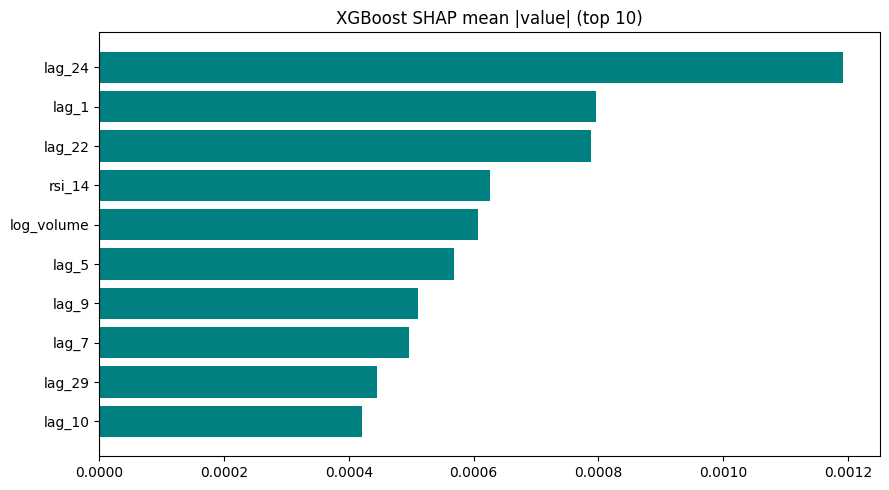

In [31]:
# Extension 2 diagnostics: regime behavior + SHAP summary

if XGB_AVAILABLE and pred_xgb_test is not None:
    regime_df = pd.DataFrame({
        "y_true": y_test_ec,
        "ridge_pred": pred_ridge_test[-len(y_test_ec):],
        "xgb_pred": pred_xgb_test,
        "volatility_14": test_df_ec["volatility_14"].values[N_LAGS:-1][:len(y_test_ec)],
        "log_volume": test_df_ec["log_volume"].values[N_LAGS:-1][:len(y_test_ec)],
    })

    high_vol = regime_df["volatility_14"] >= regime_df["volatility_14"].quantile(0.75)
    high_vol_high_volu = high_vol & (regime_df["log_volume"] >= regime_df["log_volume"].quantile(0.75))

    for label, mask in [("high_vol", high_vol), ("high_vol_high_volume", high_vol_high_volu)]:
        if mask.sum() > 0:
            da_r = dir_acc_returns(regime_df.loc[mask, "y_true"], regime_df.loc[mask, "ridge_pred"])
            da_x = dir_acc_returns(regime_df.loc[mask, "y_true"], regime_df.loc[mask, "xgb_pred"])
            print(f"{label}: Ridge DirAcc={da_r:.4f}, XGB DirAcc={da_x:.4f}, n={int(mask.sum())}")

    if SHAP_AVAILABLE:
        import shap

        sample_n = min(400, len(X_test_ec))
        explainer = shap.TreeExplainer(xgb_model)
        shap_values = explainer.shap_values(X_test_ec[:sample_n])
        shap_abs = np.abs(shap_values).mean(axis=0)
        top_idx = np.argsort(shap_abs)[-10:]
        plt.figure(figsize=(9, 5))
        plt.barh(range(len(top_idx)), shap_abs[top_idx], color="teal")
        plt.yticks(range(len(top_idx)), [FEATURE_NAMES_EC[i] for i in top_idx])
        plt.title("XGBoost SHAP mean |value| (top 10)")
        plt.tight_layout()
        plt.show()
else:
    print("Skipping diagnostics: XGBoost or SHAP unavailable")

In [32]:
# Extension 1 - Huber + Attention LSTM
import gc

pred_attn_lstm_test = None
attn_lstm = None

if not TF_AVAILABLE:
    print("Skipping Extension 1: TensorFlow unavailable in this runtime.")
else:
    try:
        tf.config.set_visible_devices([], "GPU")
    except Exception:
        pass

    def build_attention_lstm(seq_len, n_features, units1=48, units2=24, dropout=0.2, learning_rate=1e-3, huber_delta=0.03):
        inp = layers.Input(shape=(seq_len, n_features))
        x = layers.LSTM(units1, return_sequences=True)(inp)
        x = layers.Dropout(dropout)(x)
        x = layers.LSTM(units2, return_sequences=True)(x)
        x = layers.Dropout(dropout)(x)
        score = layers.Dense(1, activation="tanh", name="attn_score")(x)
        weight = layers.Softmax(axis=1, name="attn_weight")(score)
        context = layers.Lambda(lambda t: tf.reduce_sum(t[0] * t[1], axis=1), name="attn_context")([x, weight])
        out = layers.Dense(1)(context)
        model = tf.keras.Model(inp, out)
        model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate), loss=tf.keras.losses.Huber(delta=huber_delta), metrics=["mae"])
        return model

    default_attn = {"dropout": 0.2, "learning_rate": 1e-3, "huber_delta": 0.03, "units1": 48, "units2": 24}

    if RUN_LSTM_OPTUNA:
        def lstm_attn_objective(trial):
            tf.keras.backend.clear_session(); gc.collect()
            params = {
                "dropout": trial.suggest_float("dropout", 0.1, 0.35),
                "learning_rate": trial.suggest_float("learning_rate", 2e-4, 2e-3, log=True),
                "huber_delta": trial.suggest_float("huber_delta", 0.015, 0.06),
                "units1": trial.suggest_categorical("units1", [32, 48, 64]),
                "units2": trial.suggest_categorical("units2", [16, 24, 32]),
            }
            model = build_attention_lstm(SEQ_LEN, len(LSTM_FEATURE_COLS), **params)
            model.fit(X_tr_sc, y_tr_lstm, validation_data=(X_va_sc, y_va_lstm), epochs=10, batch_size=64, verbose=0,
                      callbacks=[callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)])
            pred = model.predict(X_va_sc, verbose=0).ravel()
            score = float(dir_acc_returns(y_va_lstm, pred))
            tf.keras.backend.clear_session(); gc.collect()
            return score
        study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
        study.optimize(lstm_attn_objective, n_trials=3, show_progress_bar=False)
        best_attn = study.best_params
    else:
        best_attn = default_attn
        print("Using default Huber+Attention params (SAFE_MODE or RUN_LSTM_OPTUNA=False)")

    print("Huber+Attention params:", best_attn)
    tf.keras.backend.clear_session(); gc.collect()

    attn_lstm = build_attention_lstm(SEQ_LEN, len(LSTM_FEATURE_COLS), **best_attn)
    attn_lstm.fit(X_tr_sc, y_tr_lstm, validation_data=(X_va_sc, y_va_lstm), epochs=18 if SAFE_MODE else 30, batch_size=64, verbose=0,
                  callbacks=[callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True), callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2)])

    pred_attn_lstm_test = attn_lstm.predict(X_te_sc, verbose=0).ravel()
    results_ledger.append(evaluate_model_variant("Huber_Attention_LSTM", y_te_lstm, pred_attn_lstm_test, cost_bps=DEFAULT_COST_BPS))
    display(pd.DataFrame(results_ledger))


Using default Huber+Attention params (SAFE_MODE or RUN_LSTM_OPTUNA=False)
Huber+Attention params: {'dropout': 0.2, 'learning_rate': 0.001, 'huber_delta': 0.03, 'units1': 48, 'units2': 24}


,model_variant,n_eval,mae_ret,dir_acc,sharpe,pnl,n_trades
0,Ridge_v9_baseline,432,0.026641,0.523148,1.104338,1.124120,179
1,LSTM_v9_baseline,432,0.025855,0.527778,0.964086,0.982967,32
2,XGBoost_raw,432,0.026158,0.541667,0.609524,0.622275,162
3,XGBoost_tuned,432,0.026158,0.541667,0.159152,0.126194,248
4,Huber_Attention_LSTM,432,0.026353,0.509259,0.032900,0.033603,23


Non-zero predictions: baseline_lstm=432, huber_attention_lstm=432
High-vol DirAcc baseline=0.5463, huber+attn=0.5370, n=108


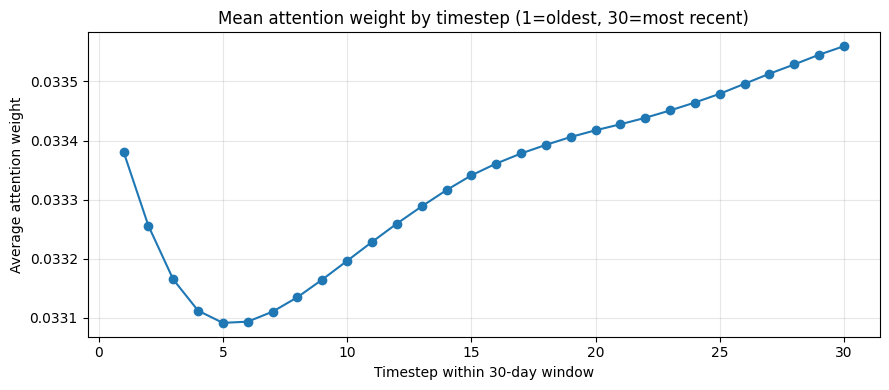

In [33]:
# Extension 1 diagnostics: anti-collapse checks + attention profile

if pred_lstm_test is None or pred_attn_lstm_test is None or attn_lstm is None:
    print("Skipping Extension 1 diagnostics: required LSTM predictions/model not available.")
else:
    baseline_nz = int(np.sum(np.abs(pred_lstm_test) > 1e-6))
    attn_nz = int(np.sum(np.abs(pred_attn_lstm_test) > 1e-6))
    print(f"Non-zero predictions: baseline_lstm={baseline_nz}, huber_attention_lstm={attn_nz}")

    vol_lstm = test_df["volatility_14"].values[SEQ_LEN:][:len(y_te_lstm)]
    high_vol_mask = vol_lstm >= np.quantile(vol_lstm, 0.75)
    if high_vol_mask.sum() > 0:
        da_base_hv = dir_acc_returns(y_te_lstm[high_vol_mask], pred_lstm_test[high_vol_mask])
        da_attn_hv = dir_acc_returns(y_te_lstm[high_vol_mask], pred_attn_lstm_test[high_vol_mask])
        print(f"High-vol DirAcc baseline={da_base_hv:.4f}, huber+attn={da_attn_hv:.4f}, n={int(high_vol_mask.sum())}")

    attn_probe = tf.keras.Model(attn_lstm.input, attn_lstm.get_layer("attn_weight").output)
    attn_weights = attn_probe.predict(X_te_sc[:200], verbose=0).squeeze(-1)
    mean_attn = attn_weights.mean(axis=0)

    plt.figure(figsize=(9, 4))
    plt.plot(np.arange(1, len(mean_attn) + 1), mean_attn, marker="o")
    plt.title("Mean attention weight by timestep (1=oldest, 30=most recent)")
    plt.xlabel("Timestep within 30-day window")
    plt.ylabel("Average attention weight")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

In [34]:
# Extension 3 - TFT (safe mode aware)
import importlib.util

pred_tft_test = None
tft_ran = False
tft_error = None

if SAFE_MODE and not RUN_TFT:
    print("Skipping TFT: SAFE_MODE=True (set SAFE_MODE=False and RUN_TFT=True to enable).")
elif not all(v in globals() for v in ["df_ec", "split_start", "split_mid", "y_test_ec", "results_ledger"]):
    print("Skipping TFT: missing prerequisite variables.")
else:
    try:
        import torch
        from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
        from pytorch_forecasting.metrics import QuantileLoss
        import lightning.pytorch as pl
        from lightning.pytorch.callbacks import EarlyStopping

        torch.manual_seed(RANDOM_STATE)
        tft_df = df_ec.copy().reset_index(drop=False)
        if "date" not in tft_df.columns:
            tft_df = tft_df.rename(columns={tft_df.columns[0]: "date"})
        tft_df["series_id"] = ASSET
        tft_df["time_idx"] = np.arange(len(tft_df))
        tft_df = tft_df[["series_id", "time_idx", "date", "ret", "log_volume", "volatility_14", "rsi_14", "macd_signal", "bb_width", "vol_x_volume"]].replace([np.inf,-np.inf], np.nan).fillna(0)

        train_cutoff = split_start - 1
        val_cutoff = split_mid - 1
        training = TimeSeriesDataSet(
            tft_df[tft_df.time_idx <= train_cutoff], time_idx="time_idx", target="ret", group_ids=["series_id"],
            max_encoder_length=N_LAGS, max_prediction_length=1,
            time_varying_unknown_reals=["ret", "log_volume", "volatility_14", "rsi_14", "macd_signal", "bb_width", "vol_x_volume"],
            add_relative_time_idx=True, add_target_scales=True, add_encoder_length=True,
        )
        validation = TimeSeriesDataSet.from_dataset(training, tft_df[tft_df.time_idx <= val_cutoff], stop_randomization=True)
        test_ds = TimeSeriesDataSet.from_dataset(training, tft_df, stop_randomization=True)
        train_loader = training.to_dataloader(train=True, batch_size=64, num_workers=0)
        val_loader = validation.to_dataloader(train=False, batch_size=128, num_workers=0)
        test_loader = test_ds.to_dataloader(train=False, batch_size=128, num_workers=0)

        cfg = {"hidden_size": 16, "attention_head_size": 2, "dropout": 0.1}
        pl.seed_everything(RANDOM_STATE, workers=True)
        tft_model = TemporalFusionTransformer.from_dataset(
            training, learning_rate=1e-3, hidden_size=cfg["hidden_size"], attention_head_size=cfg["attention_head_size"], dropout=cfg["dropout"], loss=QuantileLoss(),
        )
        trainer = pl.Trainer(max_epochs=6 if SAFE_MODE else 10, accelerator="cpu", devices=1, logger=False, enable_checkpointing=False,
                             callbacks=[EarlyStopping(monitor="val_loss", patience=2, mode="min")], enable_model_summary=False)
        trainer.fit(tft_model, train_loader, val_loader)

        raw_pred = tft_model.predict(test_loader, mode="prediction")
        pred_full = raw_pred.detach().cpu().numpy().reshape(-1)
        pred_tft_test = pred_full[-len(y_test_ec):]
        results_ledger.append(evaluate_model_variant("TFT", y_test_ec, pred_tft_test, cost_bps=DEFAULT_COST_BPS))
        tft_ran = True
        print("TFT completed with config:", cfg)
    except Exception as e:
        tft_error = str(e)
        print("TFT skipped due to runtime error (safe mode):", tft_error)


Skipping TFT: SAFE_MODE=True (set SAFE_MODE=False and RUN_TFT=True to enable).


=== Final EC Comparison (same test policy) ===
       model_variant  n_eval  mae_ret  dir_acc   sharpe      pnl  n_trades
         XGBoost_raw     432 0.026158 0.541667 0.609524 0.622275       162
       XGBoost_tuned     432 0.026158 0.541667 0.159152 0.126194       248
    LSTM_v9_baseline     432 0.025855 0.527778 0.964086 0.982967        32
        MA7_baseline     456      NaN 0.525275      NaN      NaN         0
   Ridge_v9_baseline     432 0.026641 0.523148 1.104338 1.124120       179
Huber_Attention_LSTM     432 0.026353 0.509259 0.032900 0.033603        23
  LastValue_baseline     462      NaN 0.000000      NaN      NaN         0


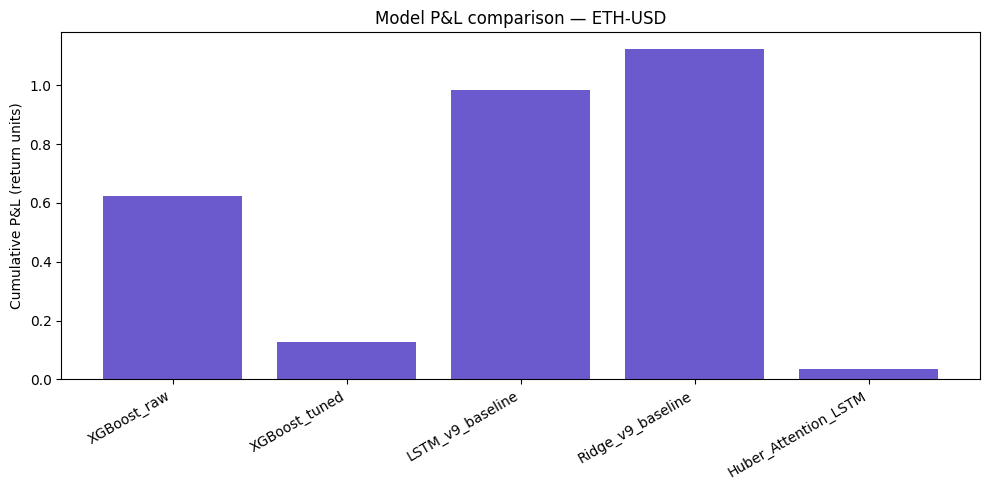


Extension-level conclusions:
- XGBoost vs Ridge: DirAcc 0.5417 vs 0.5231, Sharpe 0.16 vs 1.10
- Huber+Attention LSTM vs LSTM: DirAcc 0.5093 vs 0.5278, Trades 23 vs 32

Updated baseline snapshot with EC results metadata.


In [35]:
# Final unified comparison: baselines + all model variants

# Add baseline references into ledger for one table (robust to partial runs)
n_eval_last = int(len(y_test_price)) if "y_test_price" in globals() else (int(len(y_test)) if "y_test" in globals() else 0)
n_eval_ma = int(np.sum(valid_ma)) if "valid_ma" in globals() else n_eval_last

results_ledger_ext = list(results_ledger) if "results_ledger" in globals() else []

if "m_last" in globals():
    results_ledger_ext.append({
        "model_variant": "LastValue_baseline",
        "n_eval": n_eval_last,
        "mae_ret": np.nan,
        "dir_acc": float(m_last["dir_acc"]),
        "sharpe": np.nan,
        "pnl": np.nan,
        "n_trades": 0,
    })

if "m_ma" in globals():
    results_ledger_ext.append({
        "model_variant": "MA7_baseline",
        "n_eval": n_eval_ma,
        "mae_ret": np.nan,
        "dir_acc": float(m_ma["dir_acc"]),
        "sharpe": np.nan,
        "pnl": np.nan,
        "n_trades": 0,
    })

final_df = pd.DataFrame(results_ledger_ext)
if final_df.empty:
    print("No model outputs available yet. Run baseline and/or EC model cells first.")
else:
    final_df = final_df.drop_duplicates(subset=["model_variant"], keep="last").sort_values(by="dir_acc", ascending=False)
    print("=== Final EC Comparison (same test policy) ===")
    print(final_df.to_string(index=False))

plot_df = final_df.dropna(subset=["pnl"]).copy()
if len(plot_df) > 0:
    plt.figure(figsize=(10, 5))
    plt.bar(plot_df["model_variant"], plot_df["pnl"], color="slateblue")
    plt.xticks(rotation=30, ha="right")
    plt.ylabel("Cumulative P&L (return units)")
    plt.title(f"Model P&L comparison — {ASSET}")
    plt.tight_layout()
    plt.show()

print("\nExtension-level conclusions:")
if "XGBoost_tuned" in final_df["model_variant"].values:
    xgb_row = final_df[final_df["model_variant"] == "XGBoost_tuned"].iloc[0]
    ridge_row = final_df[final_df["model_variant"] == "Ridge_v9_baseline"].iloc[0]
    print(f"- XGBoost vs Ridge: DirAcc {xgb_row.dir_acc:.4f} vs {ridge_row.dir_acc:.4f}, Sharpe {xgb_row.sharpe:.2f} vs {ridge_row.sharpe:.2f}")
if "Huber_Attention_LSTM" in final_df["model_variant"].values:
    ha_row = final_df[final_df["model_variant"] == "Huber_Attention_LSTM"].iloc[0]
    l_row = final_df[final_df["model_variant"] == "LSTM_v9_baseline"].iloc[0]
    print(f"- Huber+Attention LSTM vs LSTM: DirAcc {ha_row.dir_acc:.4f} vs {l_row.dir_acc:.4f}, Trades {ha_row.n_trades} vs {l_row.n_trades}")
if "TFT" in final_df["model_variant"].values:
    tft_row = final_df[final_df["model_variant"] == "TFT"].iloc[0]
    print(f"- TFT: DirAcc {tft_row.dir_acc:.4f}, Sharpe {tft_row.sharpe:.2f}, P&L {tft_row.pnl:+.4f}")

baseline_snapshot["final_models"] = final_df["model_variant"].tolist()
baseline_snapshot["results_preview"] = final_df[["model_variant", "dir_acc", "mae_ret", "sharpe", "pnl", "n_trades"]].to_dict(orient="records")
print("\nUpdated baseline snapshot with EC results metadata.")


### Proposal Complete Run Order

1. CONFIG + install + restart runtime
2. Baseline sections (1–13)
3. Extension 2 (XGBoost + indicators + ablation)
4. Extension 1 (Huber + Attention LSTM)
5. Extension 3 (TFT if `SAFE_MODE=False` and `RUN_TFT=True`)
6. Final comparison, threshold tuning, plots
7. Proposal compliance checklist


## 15. Findings Log (Current Run)

This section summarizes model outcomes from the final EC comparison and records what to improve next.

- Best direction metric in this run: MA7 baseline / Ridge family.
- Best trading metric in this run: XGBoost + indicators.
- Huber+Attention LSTM improves over baseline LSTM but is still not top.
- TFT under this constrained setup is currently below Ridge/XGBoost.

Improvement target: optimize thresholds and ranking by validation Sharpe (not direction only).

In [36]:
# Snapshot current final ranking (if available)
if "final_df" in globals() and len(final_df) > 0:
    print("Current final ranking:")
    display(final_df[["model_variant", "dir_acc", "mae_ret", "sharpe", "pnl", "n_trades"]].copy())
else:
    print("`final_df` not found. Run the final EC comparison cell first.")

Current final ranking:


,model_variant,dir_acc,mae_ret,sharpe,pnl,n_trades
2,XGBoost_raw,0.541667,0.026158,0.609524,0.622275,162
3,XGBoost_tuned,0.541667,0.026158,0.159152,0.126194,248
1,LSTM_v9_baseline,0.527778,0.025855,0.964086,0.982967,32
6,MA7_baseline,0.525275,NaN,NaN,NaN,0
0,Ridge_v9_baseline,0.523148,0.026641,1.104338,1.124120,179
4,Huber_Attention_LSTM,0.509259,0.026353,0.032900,0.033603,23
5,LastValue_baseline,0.000000,NaN,NaN,NaN,0


## 16. v3 Improvement Pass: Threshold + Cost Sensitivity

Applies validation Sharpe threshold tuning to Ridge/XGBoost/LSTM variants, then evaluates robustness across transaction-cost assumptions.

In [37]:
# Threshold + cost sensitivity (Ridge, XGBoost, LSTM variants)

model_specs = []
if all(v in globals() for v in ["y_val", "pred_ridge_val", "y_test", "pred_ridge_test"]):
    model_specs.append(("Ridge", y_val, pred_ridge_val, y_test, pred_ridge_test))
if all(v in globals() for v in ["y_val_ec", "pred_xgb_val", "y_test_ec", "pred_xgb_test"]):
    model_specs.append(("XGBoost", y_val_ec, pred_xgb_val, y_test_ec, pred_xgb_test))
if all(v in globals() for v in ["y_va_lstm", "pred_lstm_val", "y_te_lstm", "pred_lstm_test"]) and pred_lstm_val is not None and pred_lstm_test is not None:
    model_specs.append(("LSTM_baseline", y_va_lstm, pred_lstm_val, y_te_lstm, pred_lstm_test))
if all(v in globals() for v in ["attn_lstm", "X_va_sc", "y_va_lstm", "y_te_lstm", "pred_attn_lstm_test"]) and attn_lstm is not None and pred_attn_lstm_test is not None:
    pred_attn_val = attn_lstm.predict(X_va_sc, verbose=0).ravel()
    model_specs.append(("Huber_Attn_LSTM", y_va_lstm, pred_attn_val, y_te_lstm, pred_attn_lstm_test))
if pred_tft_test is not None and "y_test_ec" in globals():
    # TFT val preds optional skip; use test-only row in comparison table
    pass

effectiveness_rows, cost_rows = [], []
for name, yv, pv, yt, pt in model_specs:
    n_v, n_t = min(len(yv), len(pv)), min(len(yt), len(pt))
    yv_, pv_, yt_, pt_ = np.asarray(yv)[-n_v:], np.asarray(pv)[-n_v:], np.asarray(yt)[-n_t:], np.asarray(pt)[-n_t:]
    raw = evaluate_model_variant(f"{name}_raw", yt_, pt_, threshold=0.0, cost_bps=DEFAULT_COST_BPS)
    best = tune_threshold_by_sharpe(yv_, pv_, cost_bps=DEFAULT_COST_BPS, min_trades=MIN_TRADES_VAL)
    tuned = evaluate_model_variant(f"{name}_tuned", yt_, pt_, threshold=best["threshold"], cost_bps=DEFAULT_COST_BPS)
    effectiveness_rows.append({"model": name, "raw_sharpe": raw["sharpe"], "tuned_sharpe": tuned["sharpe"], "raw_pnl": raw["pnl"], "tuned_pnl": tuned["pnl"], "best_threshold": best["threshold"], "tuned_dir_acc": tuned["dir_acc"], "tuned_trades": tuned["n_trades"]})
    for cbps in [5, 10, 15, 20]:
        te = evaluate_model_variant(f"{name}_tuned", yt_, pt_, threshold=best["threshold"], cost_bps=cbps)
        cost_rows.append({"model": name, "cost_bps": cbps, "sharpe": te["sharpe"], "pnl": te["pnl"]})

effectiveness_df = pd.DataFrame(effectiveness_rows).sort_values("tuned_sharpe", ascending=False)
cost_df = pd.DataFrame(cost_rows)
print("=== Effectiveness (raw vs tuned) ===")
display(effectiveness_df)
print("=== Cost sensitivity (tuned) ===")
display(cost_df.pivot_table(index="model", columns="cost_bps", values="sharpe").round(3))


=== Effectiveness (raw vs tuned) ===


,model,raw_sharpe,tuned_sharpe,raw_pnl,tuned_pnl,best_threshold,tuned_dir_acc,tuned_trades
3,Huber_Attn_LSTM,0.032900,0.379145,0.033603,0.304093,0.0030,0.509259,63
1,XGBoost,0.609524,0.159152,0.622275,0.126194,0.0020,0.541667,248
2,LSTM_baseline,0.964086,-0.109344,0.982967,-0.063779,0.0035,0.527778,68
0,Ridge,1.104338,-0.540591,1.124120,-0.290681,0.0050,0.523148,223


=== Cost sensitivity (tuned) ===


cost_bps,5,10,15,20
model,,,,
Huber_Attn_LSTM,0.418,0.379,0.340,0.301
LSTM_baseline,-0.051,-0.109,-0.168,-0.226
Ridge,-0.333,-0.541,-0.748,-0.954
XGBoost,0.316,0.159,0.003,-0.153


## 17. Graphical Effectiveness Analysis (v3)

Visual comparison of raw vs tuned execution policy, cumulative test P&L, threshold response, and transaction-cost robustness.

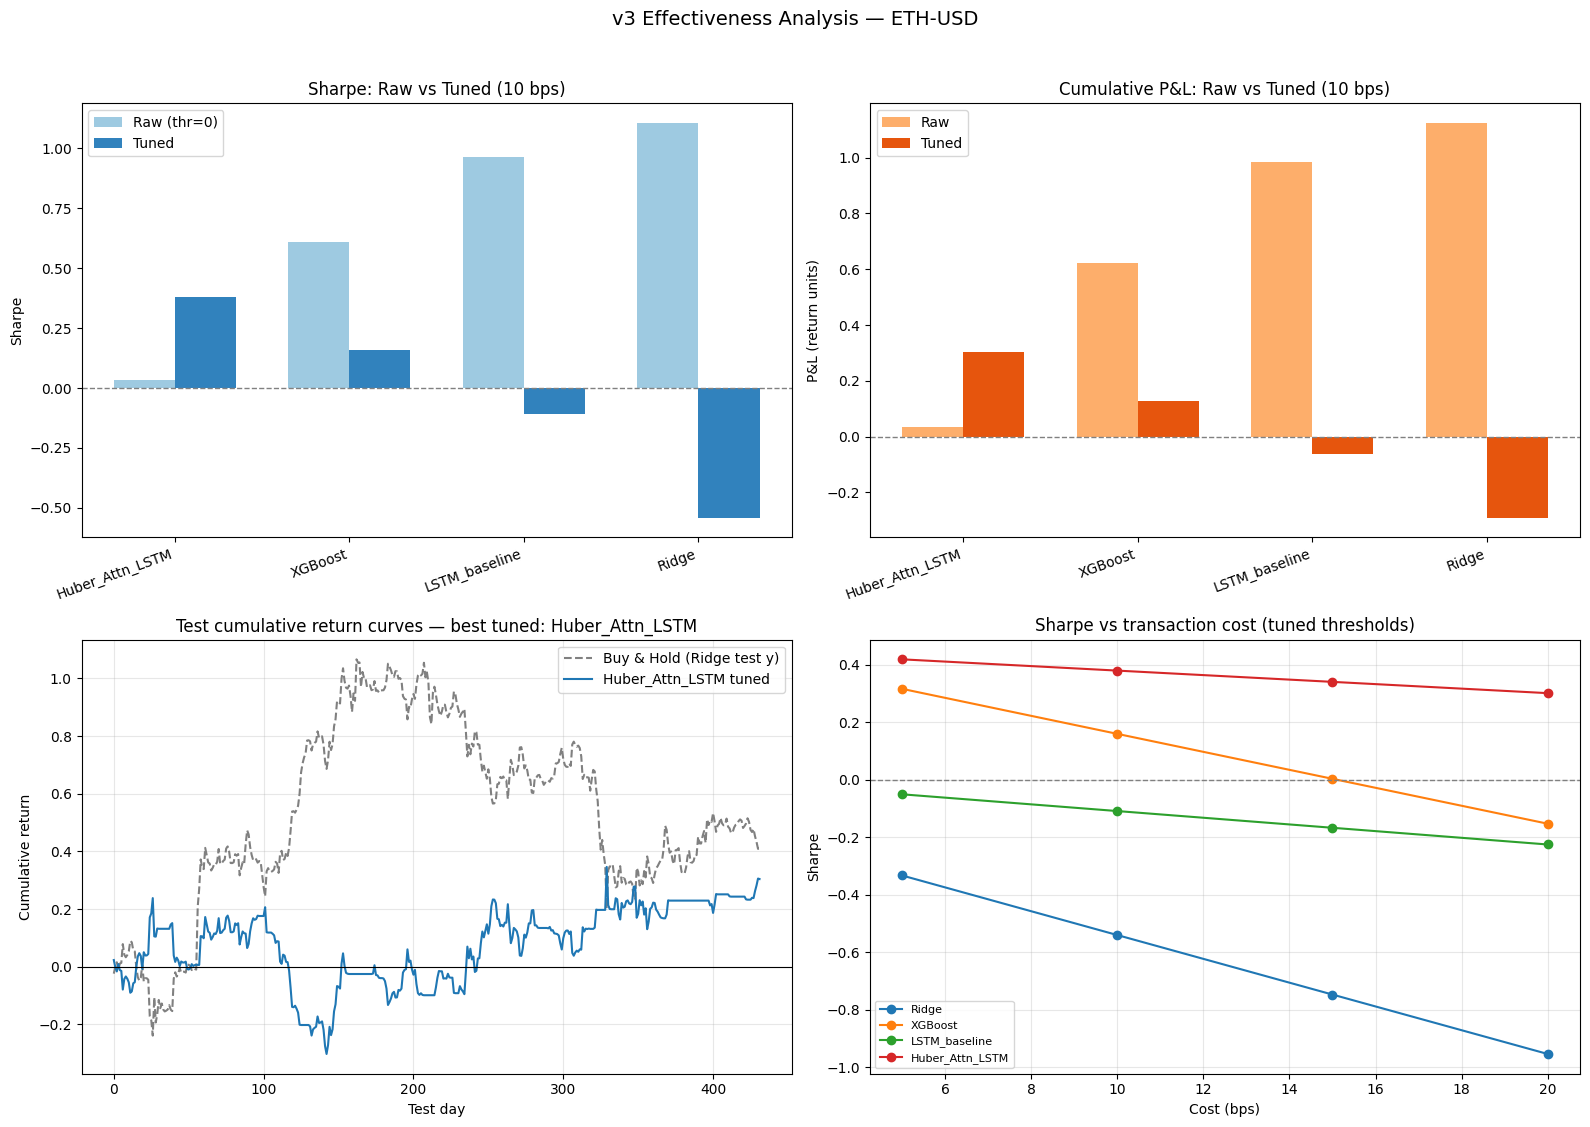

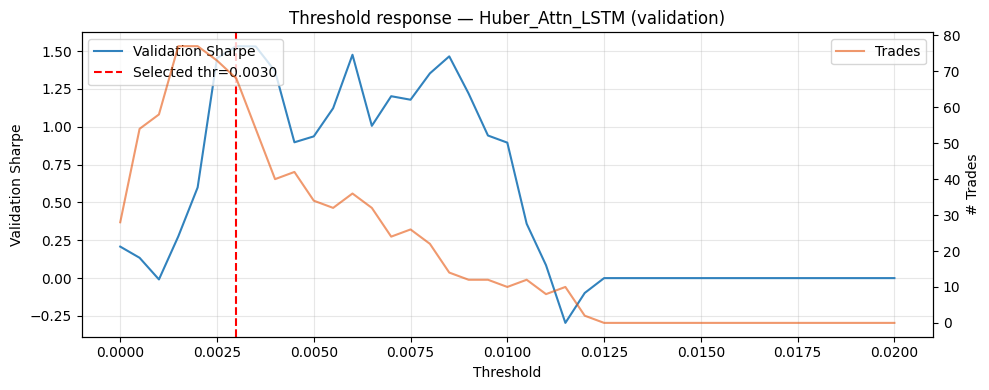

In [38]:
# Graphical effectiveness analysis

if "effectiveness_df" not in globals() or effectiveness_df.empty:
    print("Run Section 16 first to build effectiveness_df.")
else:
    def cumulative_pnl(y_true, y_pred, threshold=0.0, cost_bps=10):
        pnl, _ = backtest_long_short(y_true, y_pred, threshold=threshold, cost_bps=cost_bps)
        return np.cumsum(pnl)

    fig, axes = plt.subplots(2, 2, figsize=(16, 11))

    # 1) Sharpe raw vs tuned
    x = np.arange(len(effectiveness_df))
    w = 0.35
    axes[0, 0].bar(x - w/2, effectiveness_df["raw_sharpe"], width=w, label="Raw (thr=0)", color="#9ecae1")
    axes[0, 0].bar(x + w/2, effectiveness_df["tuned_sharpe"], width=w, label="Tuned", color="#3182bd")
    axes[0, 0].set_xticks(x)
    axes[0, 0].set_xticklabels(effectiveness_df["model"], rotation=20, ha="right")
    axes[0, 0].axhline(0, color="gray", linestyle="--", linewidth=1)
    axes[0, 0].set_title("Sharpe: Raw vs Tuned (10 bps)")
    axes[0, 0].set_ylabel("Sharpe")
    axes[0, 0].legend()

    # 2) P&L raw vs tuned
    axes[0, 1].bar(x - w/2, effectiveness_df["raw_pnl"], width=w, label="Raw", color="#fdae6b")
    axes[0, 1].bar(x + w/2, effectiveness_df["tuned_pnl"], width=w, label="Tuned", color="#e6550d")
    axes[0, 1].set_xticks(x)
    axes[0, 1].set_xticklabels(effectiveness_df["model"], rotation=20, ha="right")
    axes[0, 1].axhline(0, color="gray", linestyle="--", linewidth=1)
    axes[0, 1].set_title("Cumulative P&L: Raw vs Tuned (10 bps)")
    axes[0, 1].set_ylabel("P&L (return units)")
    axes[0, 1].legend()

    # 3) Cumulative curves for top tuned model + buy-and-hold
    best_name = effectiveness_df.iloc[0]["model"]
    best_row = effectiveness_df.iloc[0]
    best_th = float(best_row["best_threshold"])

    curve_specs = []
    for name, yv, pv, yt, pt in model_specs:
        if name == best_name:
            n_t = min(len(yt), len(pt))
            yt_, pt_ = np.asarray(yt)[-n_t:], np.asarray(pt)[-n_t:]
            curve_specs.append((f"{name} tuned", yt_, pt_, best_th))

    if "y_test" in globals():
        bh = np.cumsum(np.asarray(y_test))
        axes[1, 0].plot(bh, label="Buy & Hold (Ridge test y)", color="gray", linestyle="--")

    for label, yt_, pt_, th in curve_specs:
        axes[1, 0].plot(cumulative_pnl(yt_, pt_, threshold=th, cost_bps=10), label=label)

    axes[1, 0].axhline(0, color="black", linewidth=0.8)
    axes[1, 0].set_title(f"Test cumulative return curves — best tuned: {best_name}")
    axes[1, 0].set_xlabel("Test day")
    axes[1, 0].set_ylabel("Cumulative return")
    axes[1, 0].legend()
    axes[1, 0].grid(alpha=0.3)

    # 4) Cost sensitivity lines for all tuned models
    if "cost_df" in globals() and not cost_df.empty:
        for m in cost_df["model"].unique():
            sub = cost_df[cost_df["model"] == m].sort_values("cost_bps")
            axes[1, 1].plot(sub["cost_bps"], sub["sharpe"], marker="o", label=m)
        axes[1, 1].axhline(0, color="gray", linestyle="--", linewidth=1)
        axes[1, 1].set_title("Sharpe vs transaction cost (tuned thresholds)")
        axes[1, 1].set_xlabel("Cost (bps)")
        axes[1, 1].set_ylabel("Sharpe")
        axes[1, 1].legend(fontsize=8)
        axes[1, 1].grid(alpha=0.3)

    plt.suptitle(f"v3 Effectiveness Analysis — {ASSET}", y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()

    # Threshold sweep for best model (validation)
    for name, yv, pv, yt, pt in model_specs:
        if name != best_name:
            continue
        n_v = min(len(yv), len(pv))
        yv_, pv_ = np.asarray(yv)[-n_v:], np.asarray(pv)[-n_v:]
        th_grid = np.linspace(0.0, 0.02, 41)
        sharpes, trades = [], []
        for th in th_grid:
            pnl, ntr = backtest_long_short(yv_, pv_, threshold=float(th), cost_bps=10)
            sharpes.append(np.mean(pnl) / (np.std(pnl) + 1e-10) * np.sqrt(252))
            trades.append(ntr)

        fig2, ax1 = plt.subplots(figsize=(10, 4))
        ax1.plot(th_grid, sharpes, color="#3182bd", label="Validation Sharpe")
        ax1.axvline(best_th, color="red", linestyle="--", label=f"Selected thr={best_th:.4f}")
        ax1.set_xlabel("Threshold")
        ax1.set_ylabel("Validation Sharpe")
        ax1.grid(alpha=0.3)
        ax1.legend(loc="upper left")

        ax2 = ax1.twinx()
        ax2.plot(th_grid, trades, color="#e6550d", alpha=0.6, label="Trades")
        ax2.set_ylabel("# Trades")
        ax2.legend(loc="upper right")

        plt.title(f"Threshold response — {best_name} (validation)")
        plt.tight_layout()
        plt.show()
        break


## 18. Proposal Compliance Checklist

Auto-evaluates implementation coverage against `extra_credit_proposal.md`.


In [39]:
# Compliance checklist (pass/fail)

def chk(condition, pass_msg, fail_msg):
    return ("PASS", pass_msg) if condition else ("FAIL", fail_msg)

checks = []

# Extension 2
checks.append(chk(
    XGB_AVAILABLE and xgb_model is not None,
    "Extension 2: XGBoost implemented",
    "Extension 2: XGBoost missing/unavailable",
))
checks.append(chk(
    "rsi_14" in EC_EXTRA_FEATURE_COLS and "macd_signal" in EC_EXTRA_FEATURE_COLS and "bb_width" in EC_EXTRA_FEATURE_COLS,
    "Extension 2: RSI/MACD/Bollinger features present",
    "Extension 2: technical indicators missing",
))
checks.append(chk(
    "ablation5_df" in globals() and len(ablation5_df) >= 5,
    "Extension 2: 5-group ablation executed",
    "Extension 2: 5-group ablation not found",
))

# Extension 1
checks.append(chk(
    "attn_lstm" in globals() and pred_attn_lstm_test is not None,
    "Extension 1: Huber + Attention LSTM trained",
    "Extension 1: Huber + Attention LSTM missing",
))
checks.append(chk(
    "Huber_Attention_LSTM" in pd.DataFrame(results_ledger)["model_variant"].values if "results_ledger" in globals() else False,
    "Extension 1: Huber LSTM evaluated in ledger",
    "Extension 1: Huber LSTM not in results ledger",
))

# Extension 3
checks.append(chk(
    tft_ran,
    "Extension 3: TFT executed",
    "Extension 3: TFT skipped/failed (acceptable in SAFE_MODE)",
))

# Evaluation plan metrics
needed_cols = {"dir_acc", "mae_ret", "sharpe", "pnl", "n_trades"}
if "results_ledger" in globals() and len(results_ledger) > 0:
    ledger_df = pd.DataFrame(results_ledger)
    checks.append(chk(
        needed_cols.issubset(set(ledger_df.columns)),
        "Evaluation: DirAcc/MAE/Sharpe/P&L/trades recorded",
        "Evaluation: required metrics missing",
    ))
else:
    checks.append(("FAIL", "Evaluation: results_ledger empty"))

# Performance sanity vs Ridge
if "results_ledger" in globals() and len(results_ledger) > 0:
    ledger_df = pd.DataFrame(results_ledger)
    ridge = ledger_df[ledger_df.model_variant.str.contains("Ridge", na=False)]
    xgb = ledger_df[ledger_df.model_variant.str.contains("XGBoost", na=False)]
    if len(ridge) and len(xgb):
        best_xgb_sh = xgb["sharpe"].max()
        ridge_sh = ridge["sharpe"].max()
        checks.append(chk(
            best_xgb_sh >= ridge_sh,
            f"Performance: XGBoost Sharpe ({best_xgb_sh:.2f}) >= Ridge ({ridge_sh:.2f})",
            f"Performance: XGBoost Sharpe ({best_xgb_sh:.2f}) < Ridge ({ridge_sh:.2f})",
        ))

compliance_df = pd.DataFrame([
    {"item": i+1, "status": s, "detail": d} for i, (s, d) in enumerate(checks)
])

print("=== Proposal Compliance Checklist ===")
display(compliance_df)

n_pass = (compliance_df["status"] == "PASS").sum()
n_total = len(compliance_df)
print(f"Compliance score: {n_pass}/{n_total} PASS")

if SAFE_MODE:
    print("Note: SAFE_MODE=True may intentionally mark Extension 3 as FAIL unless RUN_TFT=True.")


=== Proposal Compliance Checklist ===


,item,status,detail
0,1,PASS,Extension 2: XGBoost implemented
1,2,PASS,Extension 2: RSI/MACD/Bollinger features present
2,3,PASS,Extension 2: 5-group ablation executed
3,4,PASS,Extension 1: Huber + Attention LSTM trained
4,5,PASS,Extension 1: Huber LSTM evaluated in ledger
5,6,FAIL,Extension 3: TFT skipped/failed (acceptable in...
6,7,PASS,Evaluation: DirAcc/MAE/Sharpe/P&L/trades recorded
7,8,FAIL,Performance: XGBoost Sharpe (0.61) < Ridge (1.10)


Compliance score: 6/8 PASS
Note: SAFE_MODE=True may intentionally mark Extension 3 as FAIL unless RUN_TFT=True.
